In [19]:
import os
import jax
import zodiax as zdx
from zodiax.optimisation import sgd, adam
from jax import numpy as np, random as jr

jax.config.update("jax_enable_x64", True)

import amigo
import dorito
import astropy

# from optim_funcs import sgd, adam

# visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots
import cmasher as cmr

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)

In [20]:
from socket import gethostname

if gethostname() == "glinton":
    cache = "/media/morgana1/snert/max/data/amigo_files/"
    data_path = "/media/morgana1/snert/max/data/JWST/WR137/calslope/"
    uncal_path = "/media/morgana/1snert/max/data/JWST/WR137/uncal/"
else:
    cache = "/Volumes/morgana1/snert/max/data/amigo_files/"
    data_path = "/Users/mcha5804/JWST/WR137/calslope/"
    uncal_path = "/Users/mcha5804/JWST/WR137/uncal/"
fisher_cache = os.path.join(cache, "fishers/")
model_cache = os.path.join(cache, "models/")
teff_cache = os.path.join(cache, "Teffs/")
init_state_cache = os.path.join(cache, "init_states/WR137/")
output_path = os.path.join(cache, "outputs/WR137/")

state = np.load(os.path.join(model_cache, "static_model.npy"), allow_pickle=True).item()

EXP_TYPE = "NIS_AMI"
FILTERS = [
    "F480M",
    # "F430M",
    # "F380M",
    # "F277W",
]

# Bind file path, type and exposure type
file_fn = lambda data_path, filters=FILTERS, **kwargs: amigo.files.get_files(
    # "/Users/mcha5804/JWST/ERS1373/calgrps/",
    data_path,
    "calslope",
    EXP_TYPE=EXP_TYPE,
    FILTER=filters,
    **kwargs,
)

# Loading in data

In [21]:
files = sorted(
    file_fn(data_path), key=lambda hdu: hdu[0].header.get("EXPMID", float("inf"))
)
# nsci = 1; ncal = 4
rolls = {}
sci_files = []
cal_files = []

for file in files:

    filename = file[0].header["FILENAME"].replace("_nis_calslope.fits", "")
    rolls[filename] = dorito.plotting.calc_parang(file)

    # manual bad pixel correction
    file["BADPIX"].data[58, 67] = 1
    file["BADPIX"].data[71, 22] = 1
    file["BADPIX"].data[65, 41] = 1
    file["BADPIX"].data[35, 70] = 1
    file["BADPIX"].data[70, 55] = 1
    file["BADPIX"].data[5, 5] = 1
    file["BADPIX"].data[-4, 37] = 1

    file["BADPIX"].data[:, :3] = 1
    file["BADPIX"].data[:, -3:] = 1
    file["BADPIX"].data[:3, :] = 1
    file["BADPIX"].data[-3:, :] = 1
    # file["BADPIX"].data[36:66, :25] = 1  # BACKGROUND STAR?
    # file["BADPIX"].data[40, 45] = 1  # MIDDLE PIXELS

    if not bool(file[0].header["IS_PSF"]):
        sci_files.append(file)
    elif bool(file[0].header["IS_PSF"]):
        file[0].header["TARGPROP"] = "HD 228337"
        cal_files.append(file)
    else:
        print(f"Unkown target: {file[0].header['TARGPROP']}")

# dorito.misc.truncate_files(cal_files, 5)
# dorito.misc.truncate_files(sci_files, 18)
# truncate_files(sci_files, 18)

In [4]:
from amigo.ramp_models import DFRNN, RNNRamp
from amigo.detector_models import PixelSensitivity

dfnrnn_model = DFRNN(jr.key(0))
ramp_model = RNNRamp(dfnrnn_model, gain_model=PixelSensitivity(), norm=2**14)
ramp_model.values.size

11232

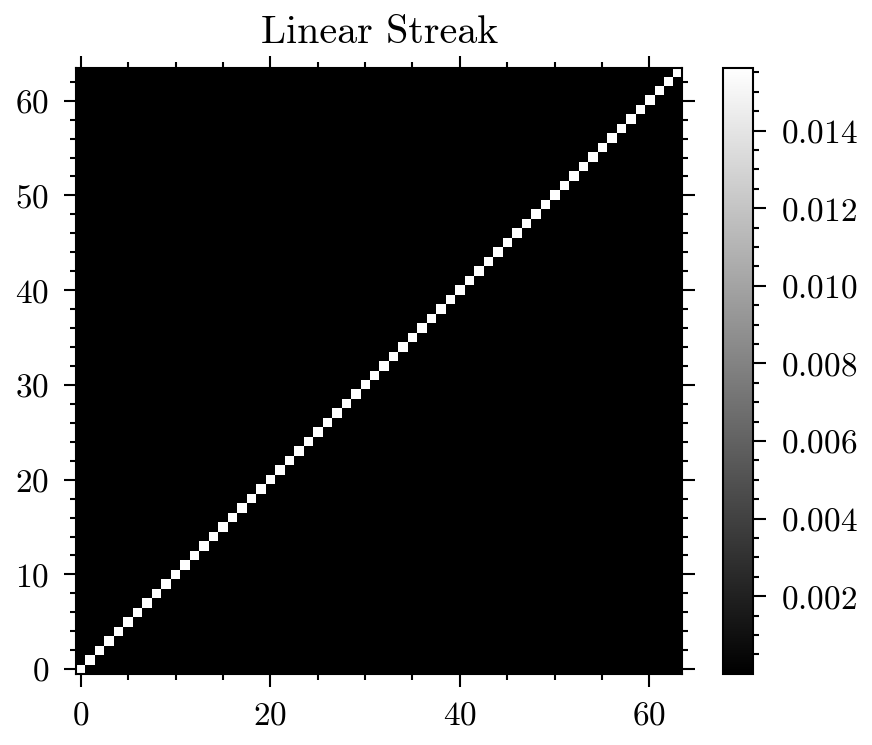

In [22]:
import numpy

# Create a 256x256 array filled with zeros
image = numpy.zeros((64, 64))

# Define the linear streak
for i in range(64):
    image[i, i] = 1  # Diagonal streak

image += 1e-6
image = np.array(image / image.sum())

# Display the image
plt.imshow(image, cmap="gray")
plt.title("Linear Streak")
plt.colorbar()
plt.show()

In [23]:
source_size = 60

model, params, cal_fits, sci_fits = dorito.build_model.build_resolved_model(
    # model, params, cal_exposures, sci_exposures = dorito.build_model.build_resolved_model(
    # cal_files,
    [],
    # sci_files[3:8],
    # cal_files[0:1],
    sci_files[0:2],
    # [],
    state=state,
    # oversample=3,
    modeller=dorito.models.ResolvedAmigoModel,
    # modeller=WaveletModel,
    # wavelets=wavelets,
    ramp_model=ramp_model,
    extra_priors={
        # "approx": np.log10(wavelets.approx),
        # "details": wavelets.values,
        "log_distribution": np.log10(image / image.sum()),
        # "log_distribution": np.log10(
        #     np.ones((source_size, source_size)) / source_size**2
        # ),
        "position_angles": np.array([0.0]),
        # "spectral_coeffs": np.array([1.0, 0.0]),
    },
    cal_fit=UniqueAbFit,
    # sci_fit=dorito.model_fits.DynamicResolvedFit,
    sci_fit=ResolvedFit,
    separate_fits=True,
    rotate=True,
)
fits = [*cal_fits, *sci_fits]

model = model.set(
    "params.position_angles",
    {fit.key: ang for fit, ang in zip(sci_fits, [30, 90])},
)
model = model.set(
    "params.positions",
    {fit.key: np.array([0.0, 0.0]) for fit in sci_fits},
)


# This seems to fix some recompile issues
def fn(x):
    if isinstance(x, jax.Array):
        if "i" in x.dtype.str:
            return x
        return np.array(x, dtype=float)
    return x


model = jax.tree.map(fn, model)

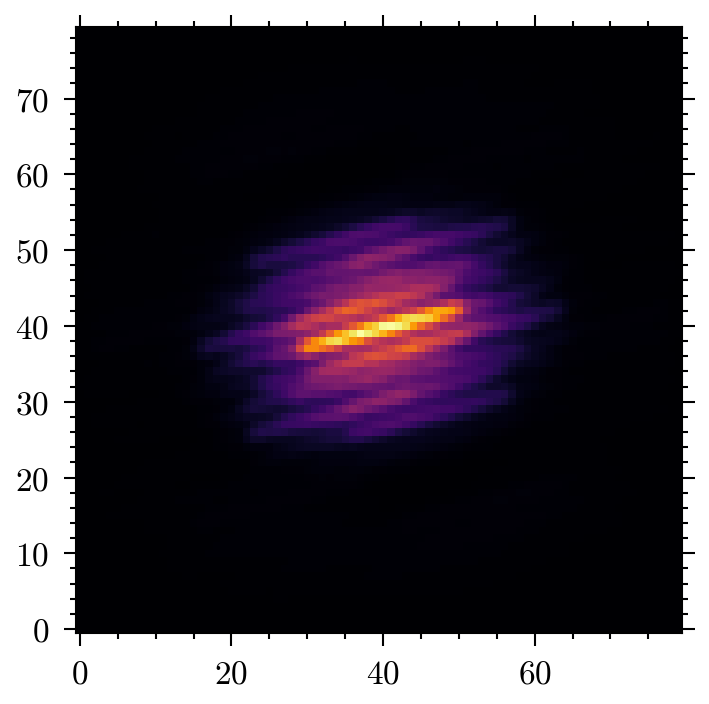

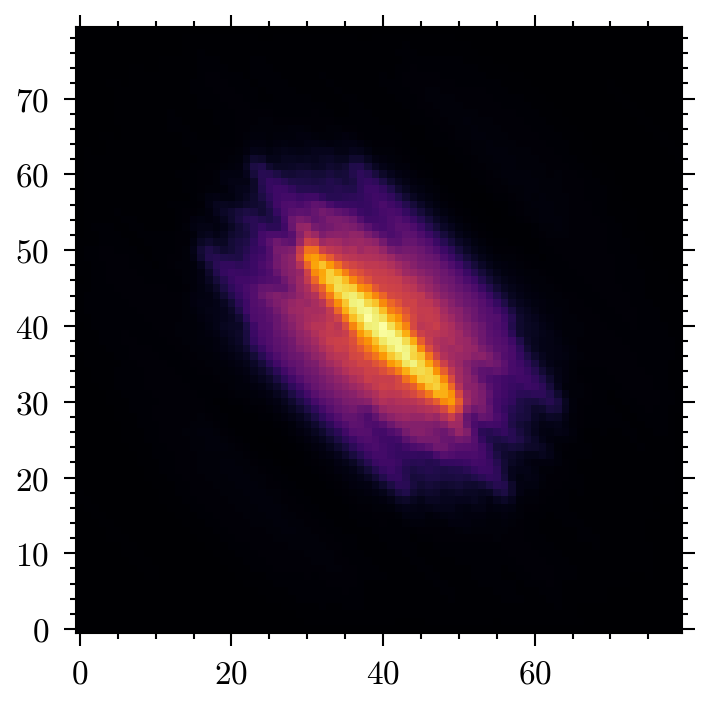

In [25]:
for expo in sci_fits:
    plt.imshow(expo(model)[-1])
    plt.show()

In [26]:
sci_keys = []
for exp in fits:
    if not exp.calibrator:
        sci_keys.append(exp.map_param("positions"))


def kill_pos_grads(model, grads, args):
    grads = grads.multiply(sci_keys, 0.0)
    return grads, args


eps = 1e1


def term_looper(looper, loss_dict):
    loss = np.array([v[-1] for v in loss_dict.values()]).mean(0)
    looper.set_description(f"Loss: {loss:.2f}")

    if len(list(loss_dict.values())[0]) > 10:
        last_loss = np.array([v[-2] for v in loss_dict.values()]).mean(0)
        if np.abs(last_loss - loss) < eps:
            return True

    return False

In [12]:
n_epoch = 150

config = {
    "positions": sgd(5e-4, 30),
    # "positions": sgd(2e-1, 0),
    "fluxes": sgd(2e-1, 0),
    # "spectra": sgd(3e-1, 0),
    "spectra": sgd(8e-5, 10),
    # "aberrations": sgd(5e-2, 4),
    "log_distribution": adam(5e-2, 0),  # , (10, 0.25), b1=0.7),
    # "fluxes": sgd(2e-1, 20),
    # "log_distribution": adam(5e-2, 5),  # , (10, 0.25), b1=0.7),
    # "positions": sgd(2e-2, 5),
    # "fluxes": sgd(2e-2, 0),
    # "one_on_fs": sgd(1e2, 6),
    # "approx": adam(1e-5, 0),
    # "approx": adam(6e-3, 8),
    # "details": adam(6e-9, 15),
    # "approx": adam(2e-2, 8),
    # "details": adam(2e-8, 15),
    # "source_spectrum.coefficients": sgd(1e-1, 5),
}

reg_dict = {
    # "L1": 1.0e0,
    # "L1": 3.0e-1,
    # "L2": None,
    # "TV": None,
    # "QV": 1.0e6,
    # "QV": 1.0e-3,
    # "ME": 1.0e2,
    # "SF": 1e3,
}

args = {
    "reg_dict": reg_dict,
    # # "reg_func_dict": dorito.stats.reg_func_dict,
    "reg_func_dict": {
        "L1": L1_REG,
        # "L1": dorito.stats.L1_on_wavelets,
        # "L1": L1_on_wavelets,
        # "QV": dorito.stats.TSV,
        "ME": dorito.stats.ME,
    },
    # "mask": mask,
}

trainer = amigo.fitting.Trainer(
    dorito.stats.regularised_loss_fn,
    norm_fn=dorito.stats.normalise_distribution,
    # grad_fn=kill_pos_grads,
    cache=fisher_cache,
    looper_fn=term_looper,
)

trainer = trainer.update_fishers(
    model.set("detector.ramp.bleed", False),
    # model,
    fits,
    args=args,
    verbose=True,
    parameters=[
        "positions",
        "fluxes",
        "aberrations",
        "spectra",
        # "one_on_fs",
        # "log_distribution",
        # "spectral_coeffs",
    ],
)

# Train the model
result = trainer.train(
    model=model,
    # model=model.set("ramp.bleed", True),
    # model=model.set("ramp.values", np.zeros_like(model.ramp.values)),
    optimisers=config,
    epochs=n_epoch,
    batches=fits,
    args=args,
)

# balance = dorito.stats.prior_data_balance(final_model, fits[-1], args)
# print(f"Likelihood: {balance[0]:.3e}, Prior: {balance[1]:.3e}")

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 95,462,018.65
Estimated run time: 0:02:59
Full Time: 0:04:03
Final Loss: 3,233,407.02


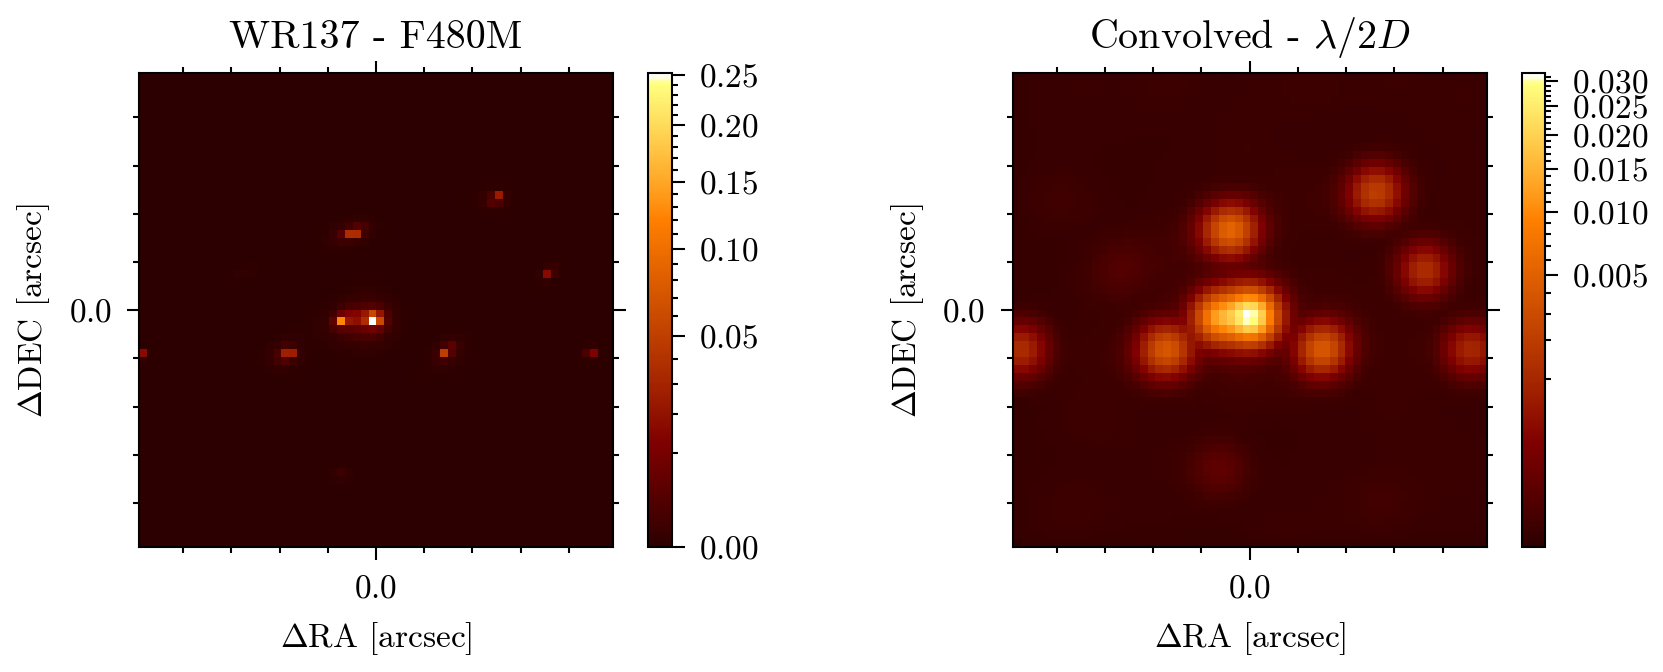

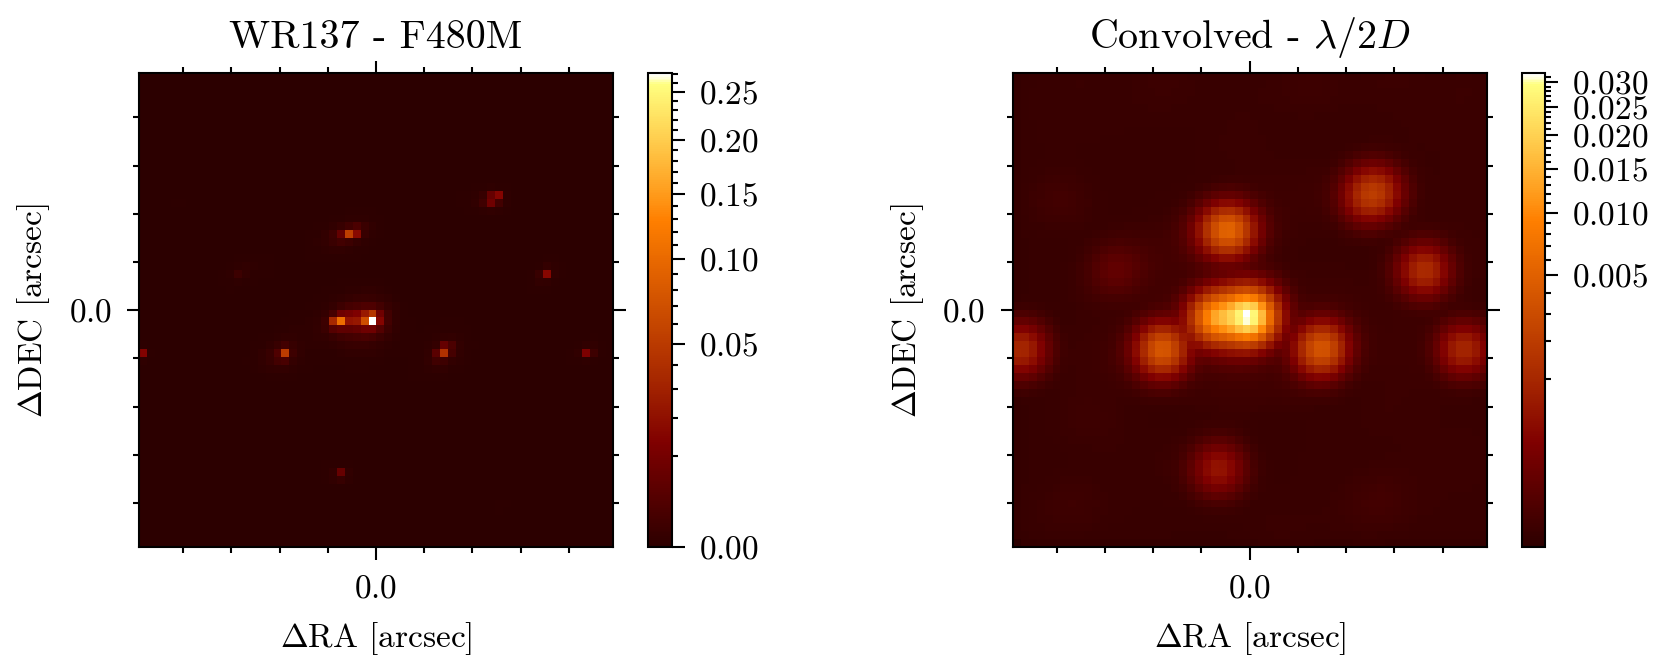

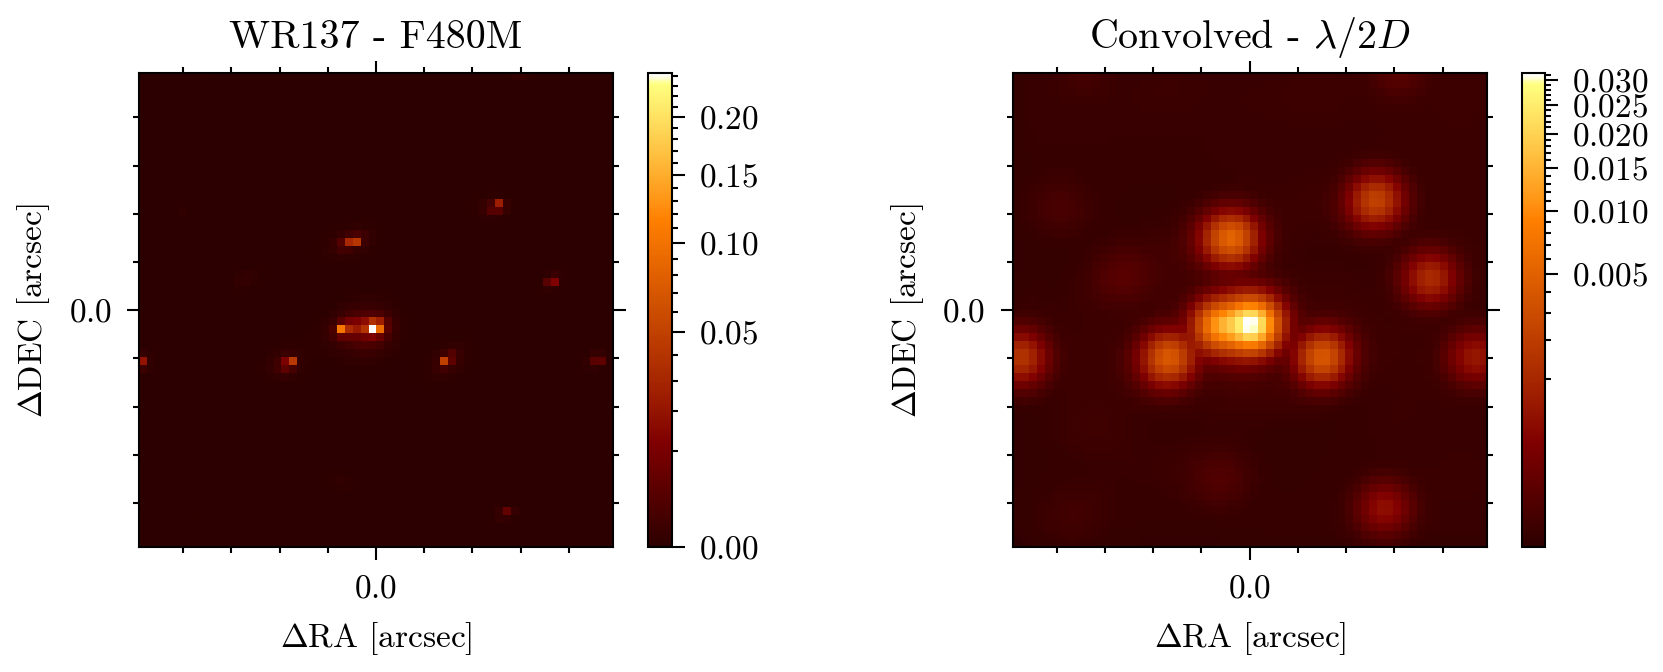

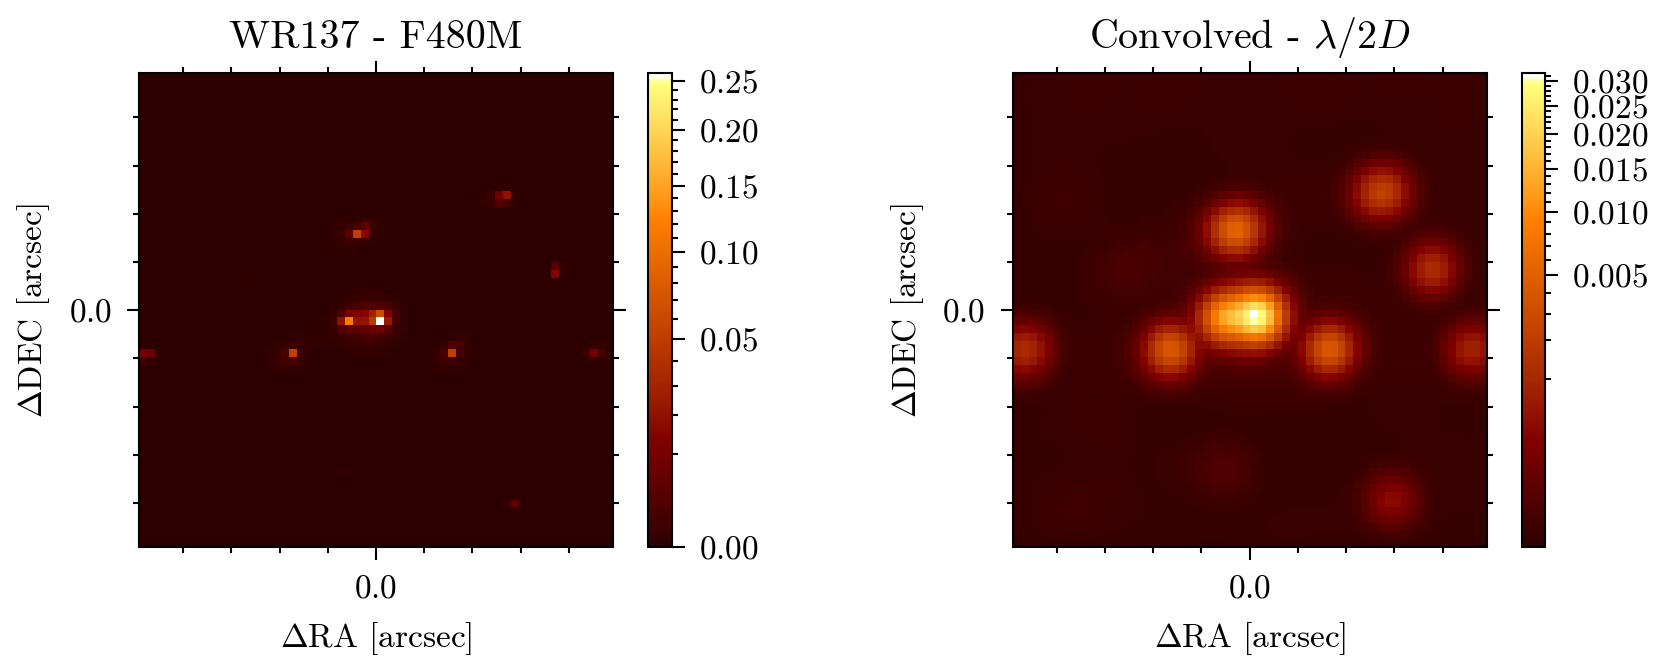

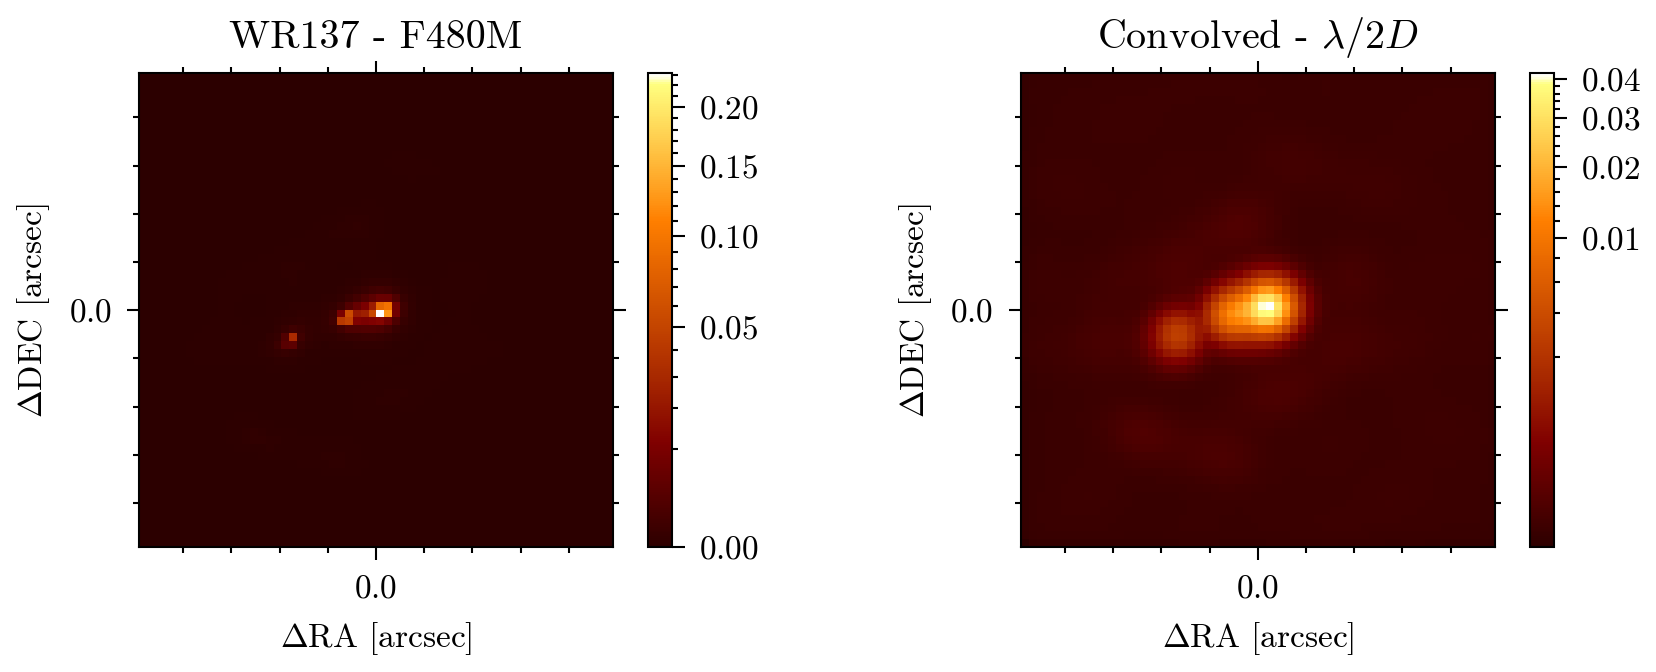

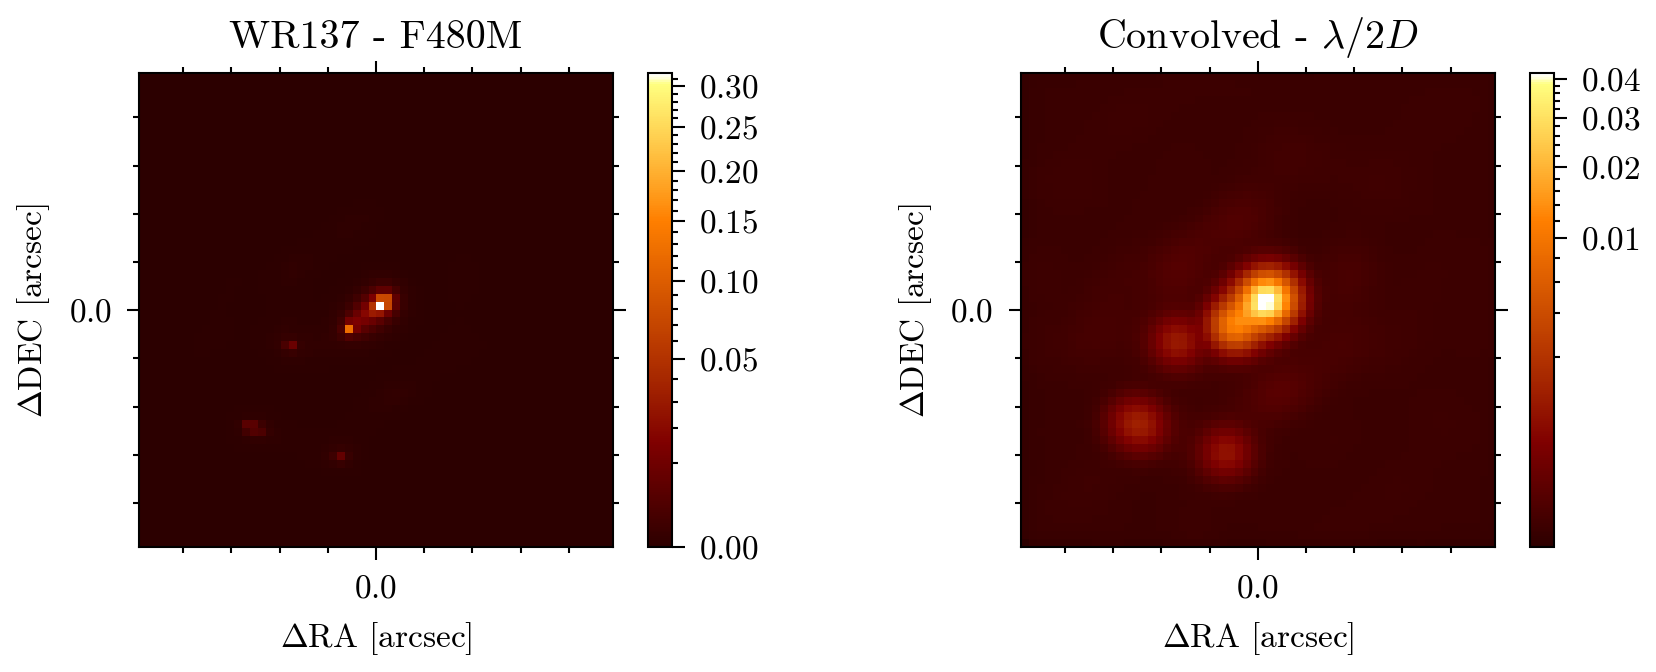

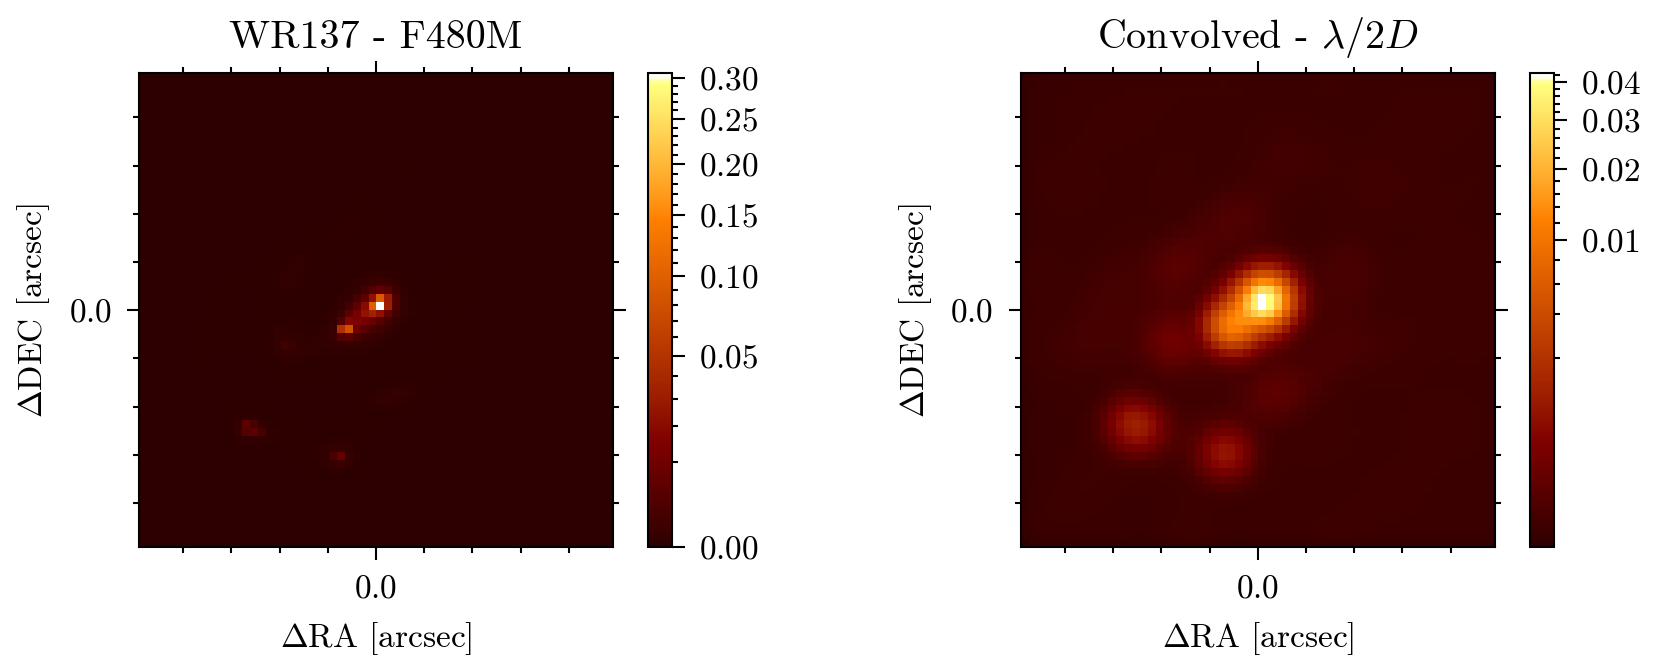

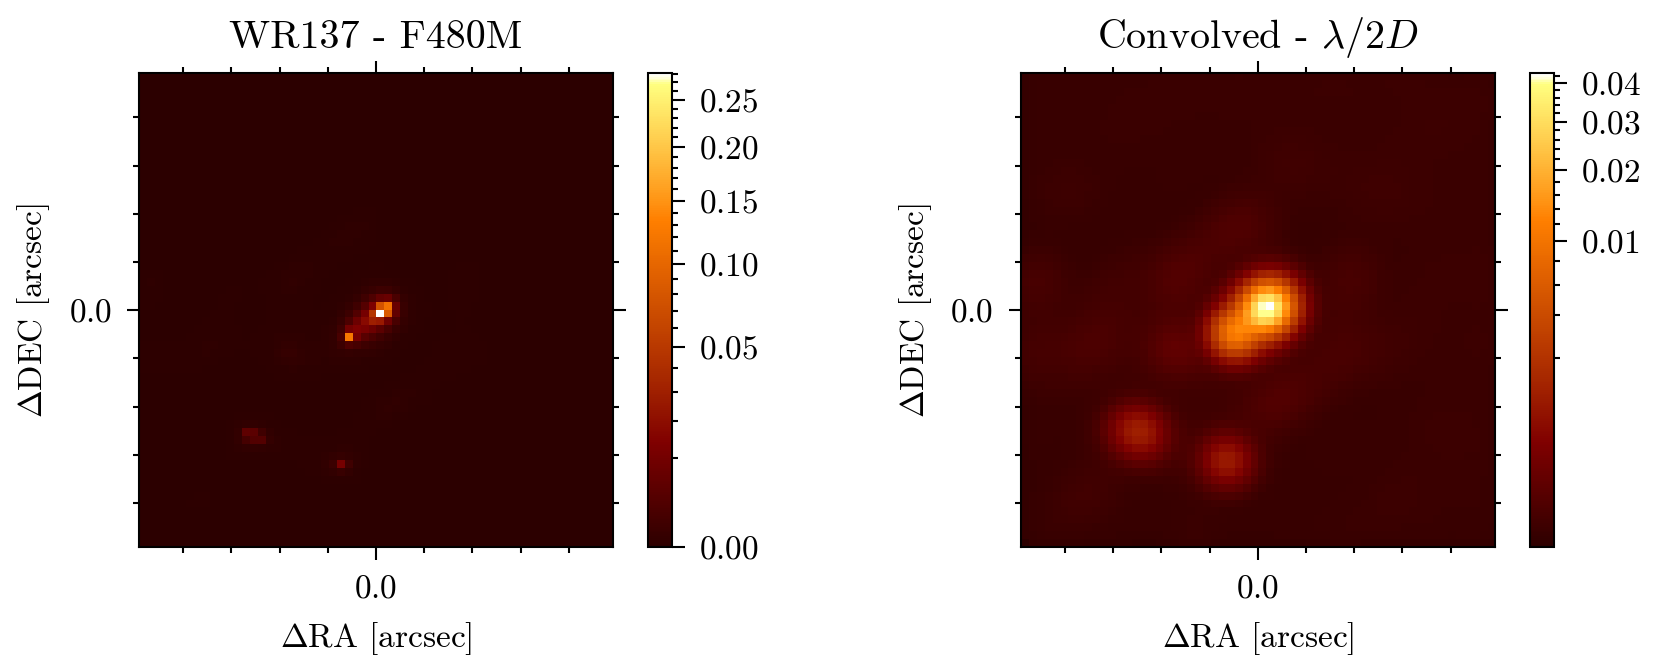

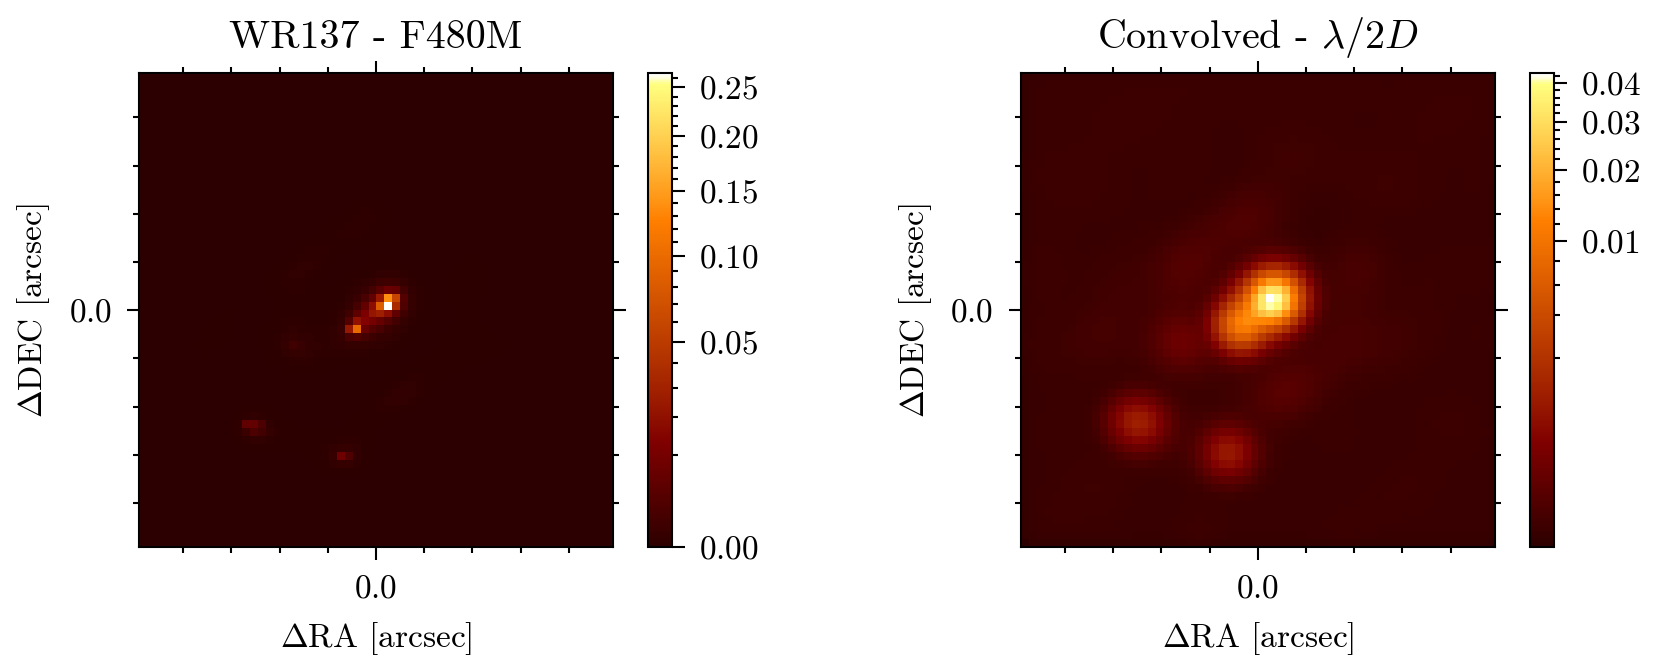

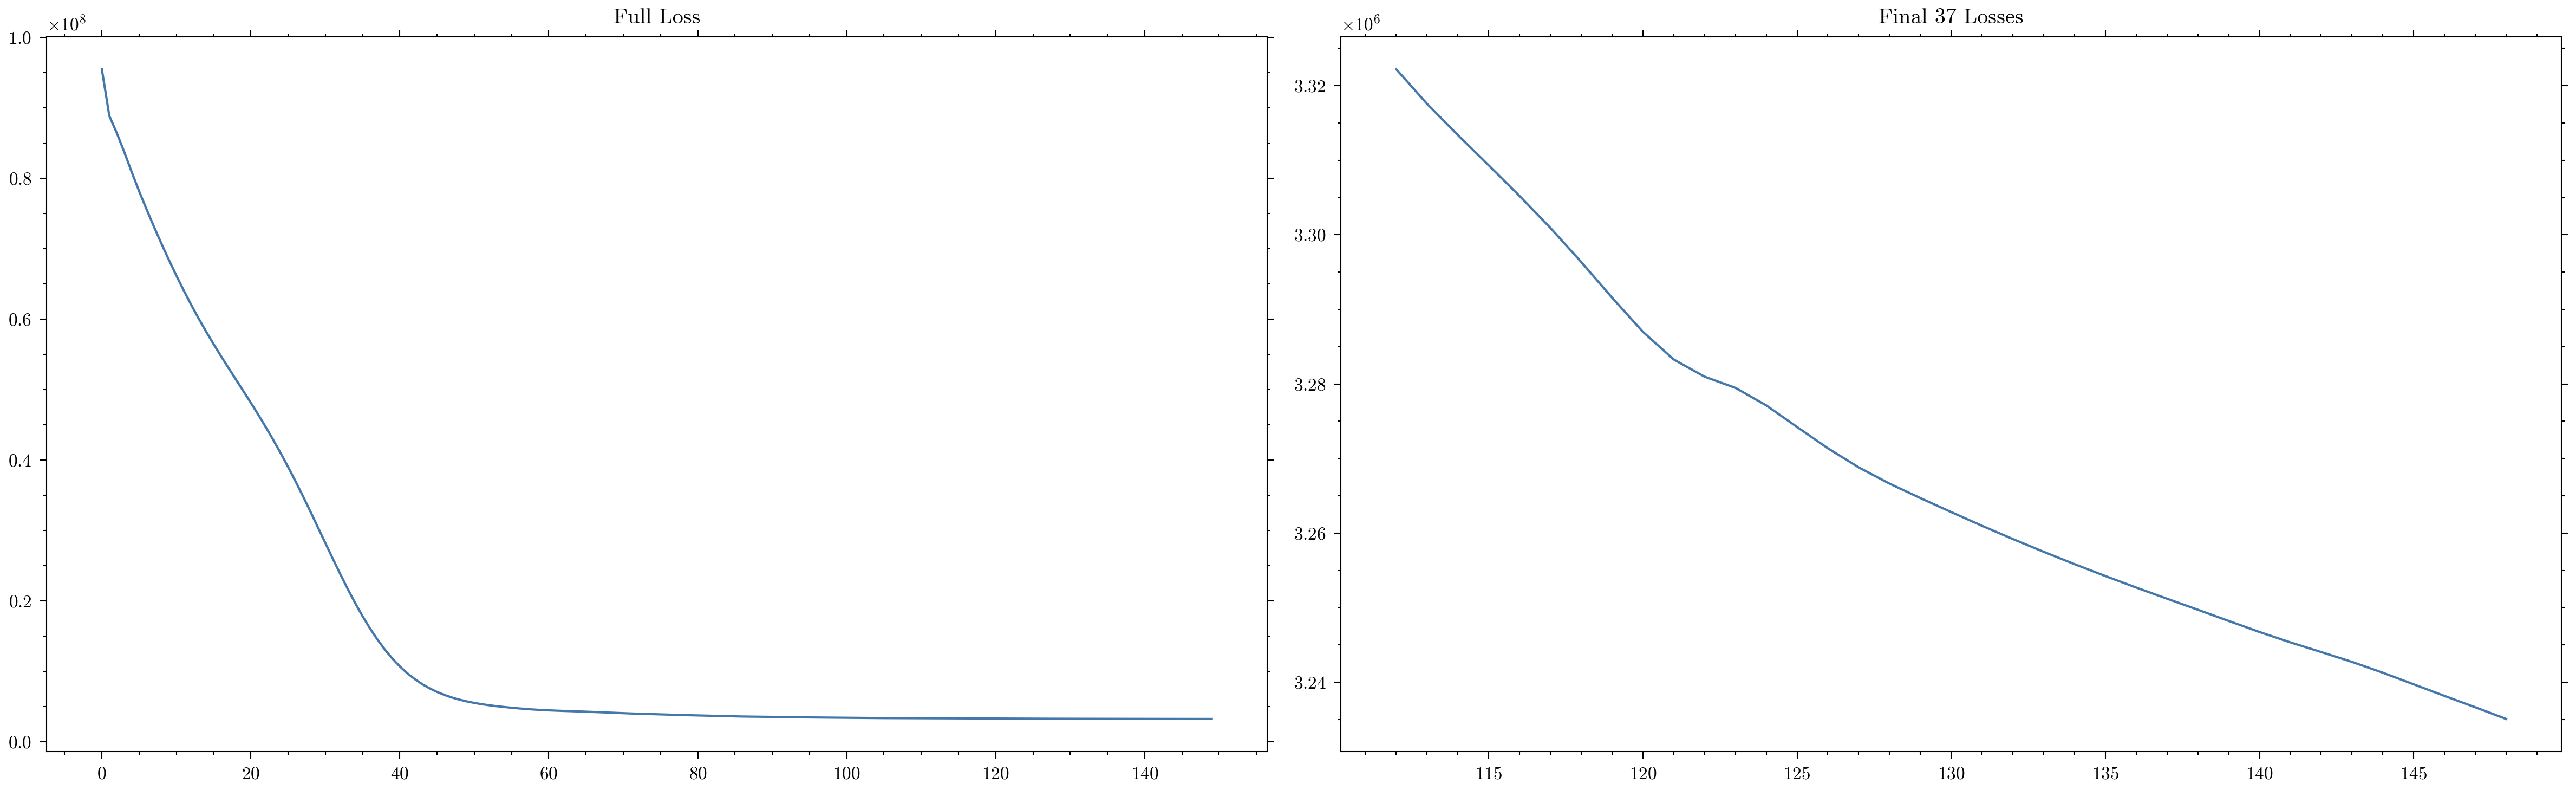

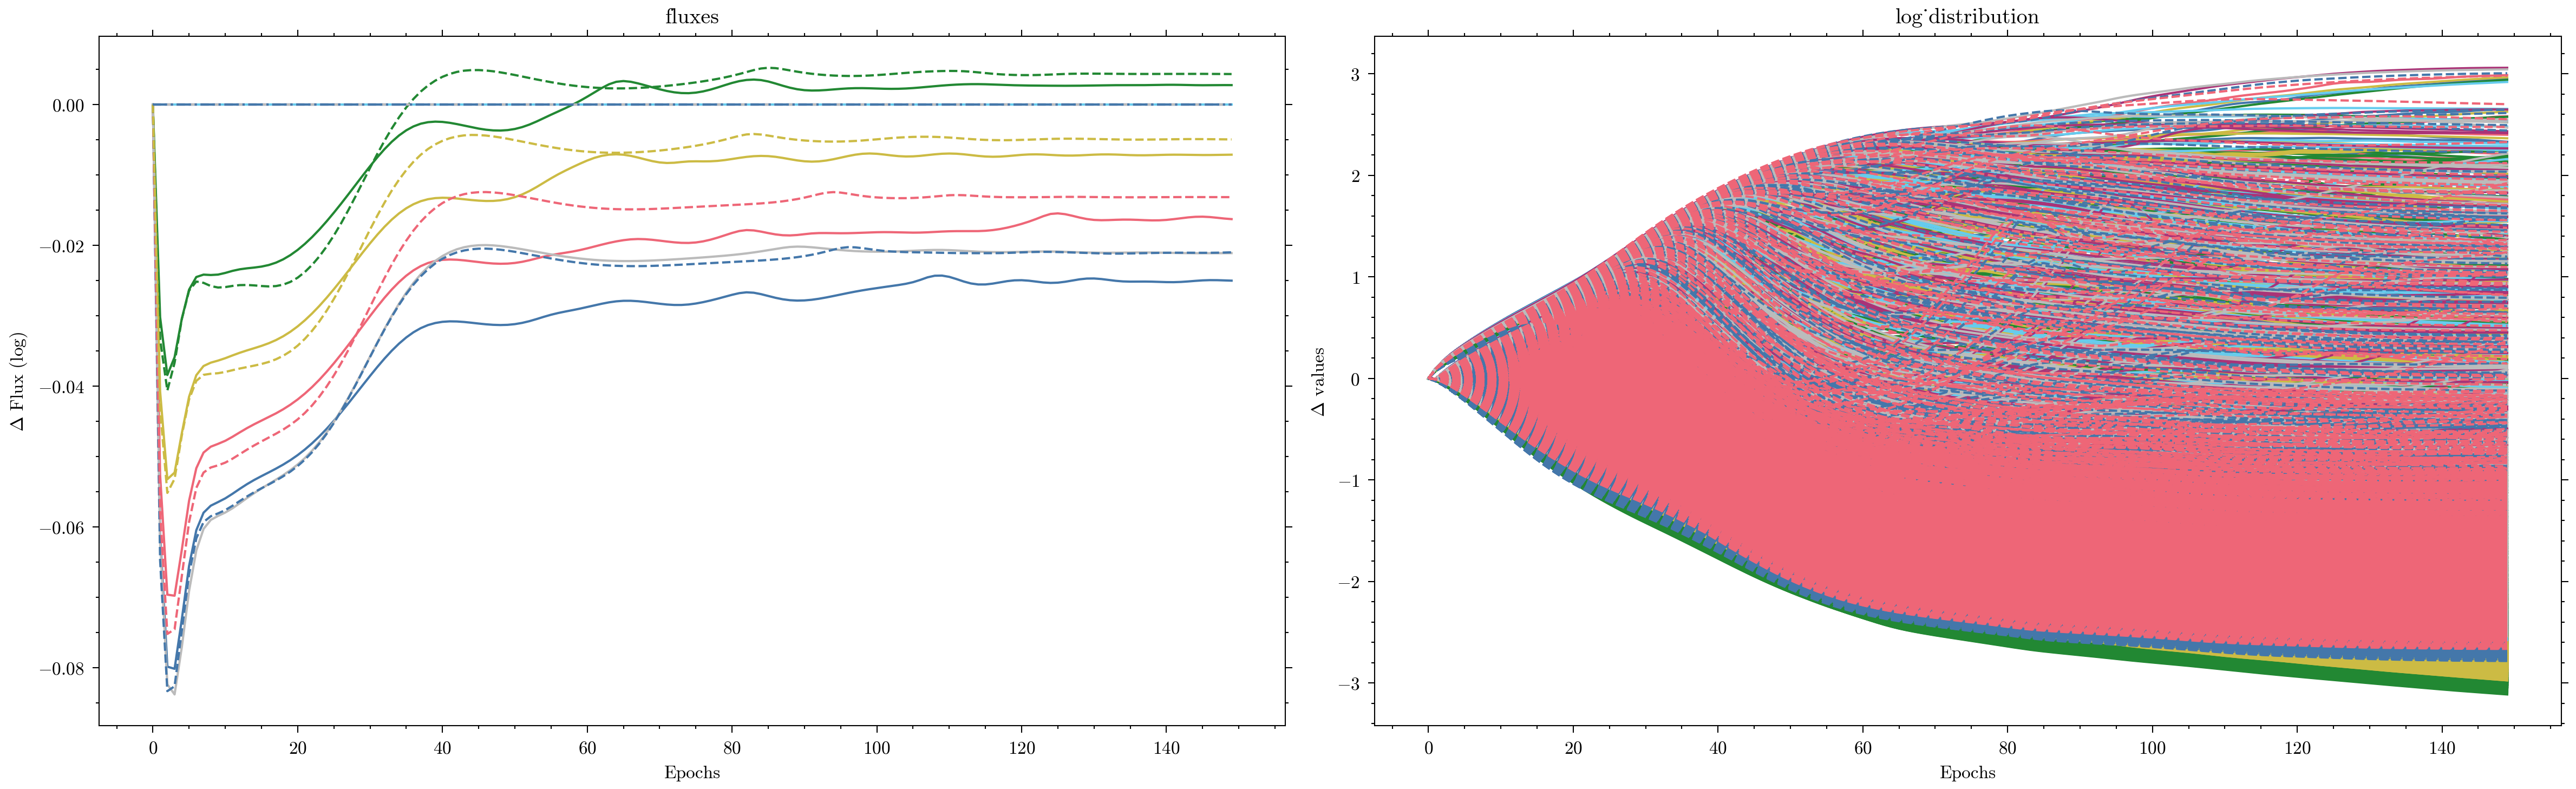

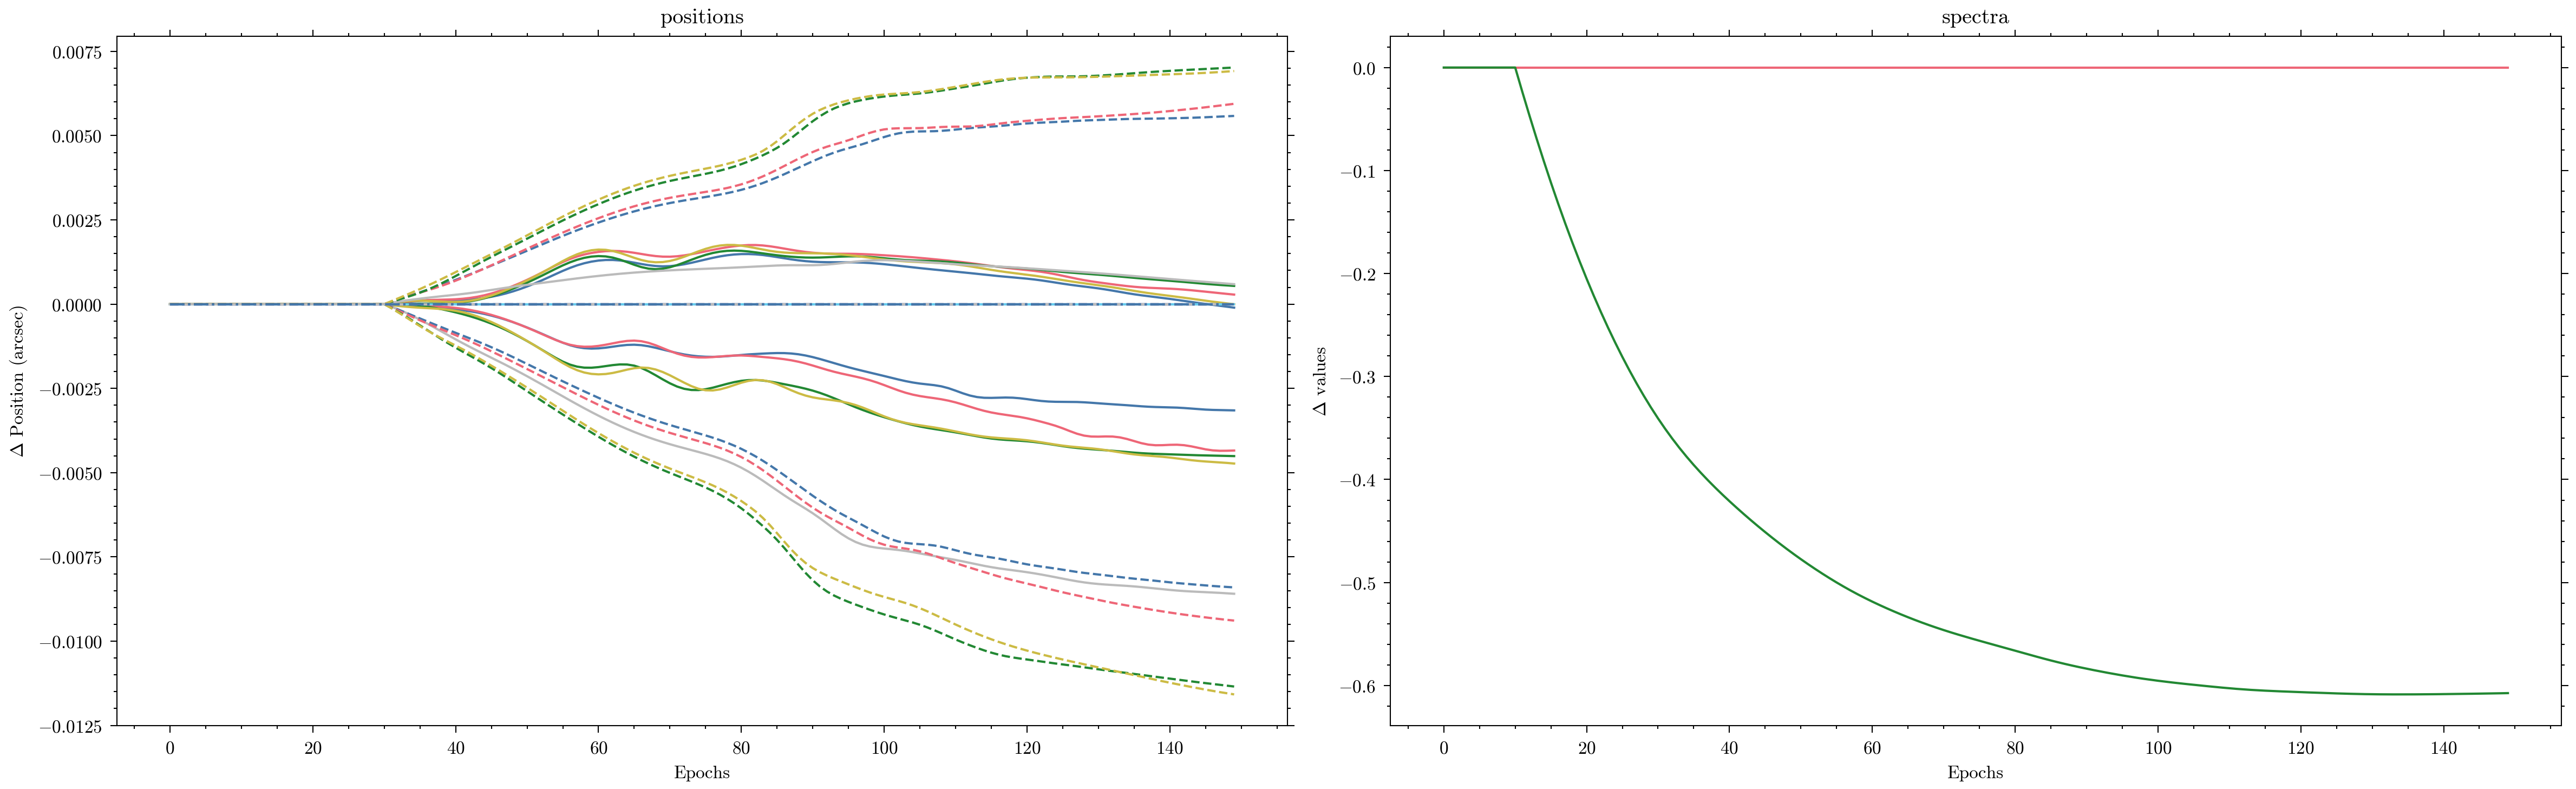

File 01349_003_02_03_1
Star WR137
Filter F480M
nints 400
ngroups 4

191.4435589852355


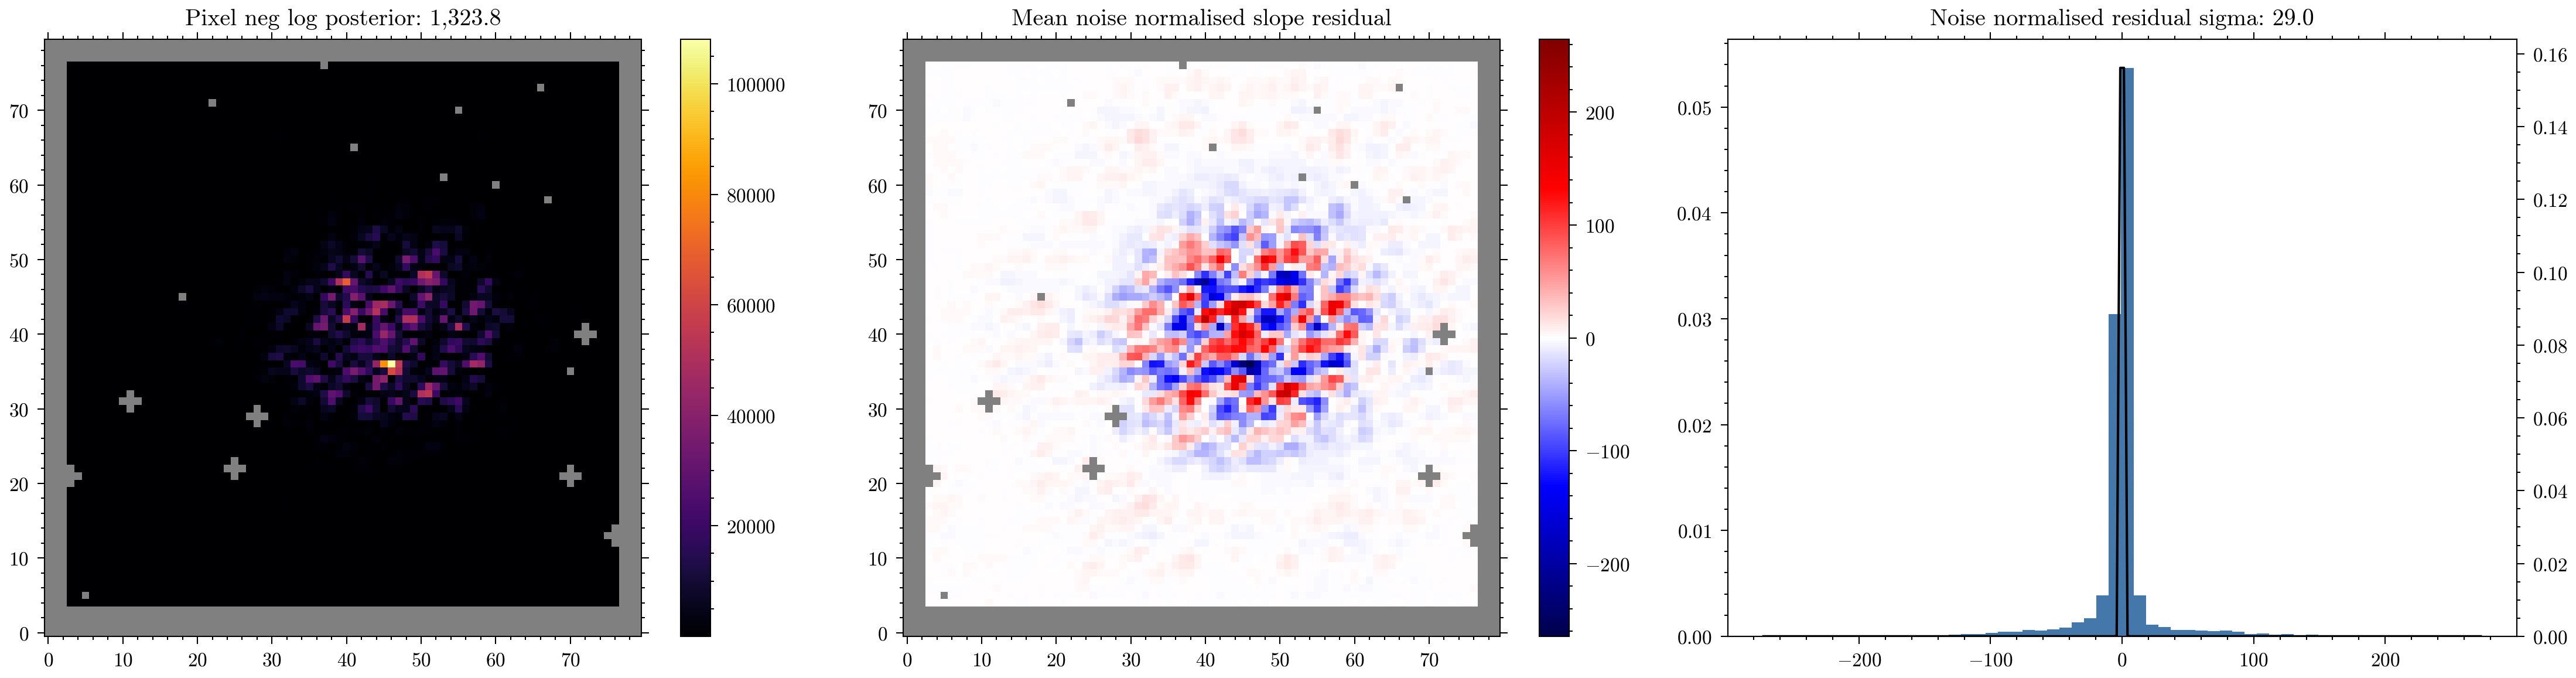

File 01349_003_02_03_2
Star WR137
Filter F480M
nints 400
ngroups 4

191.4437907245513


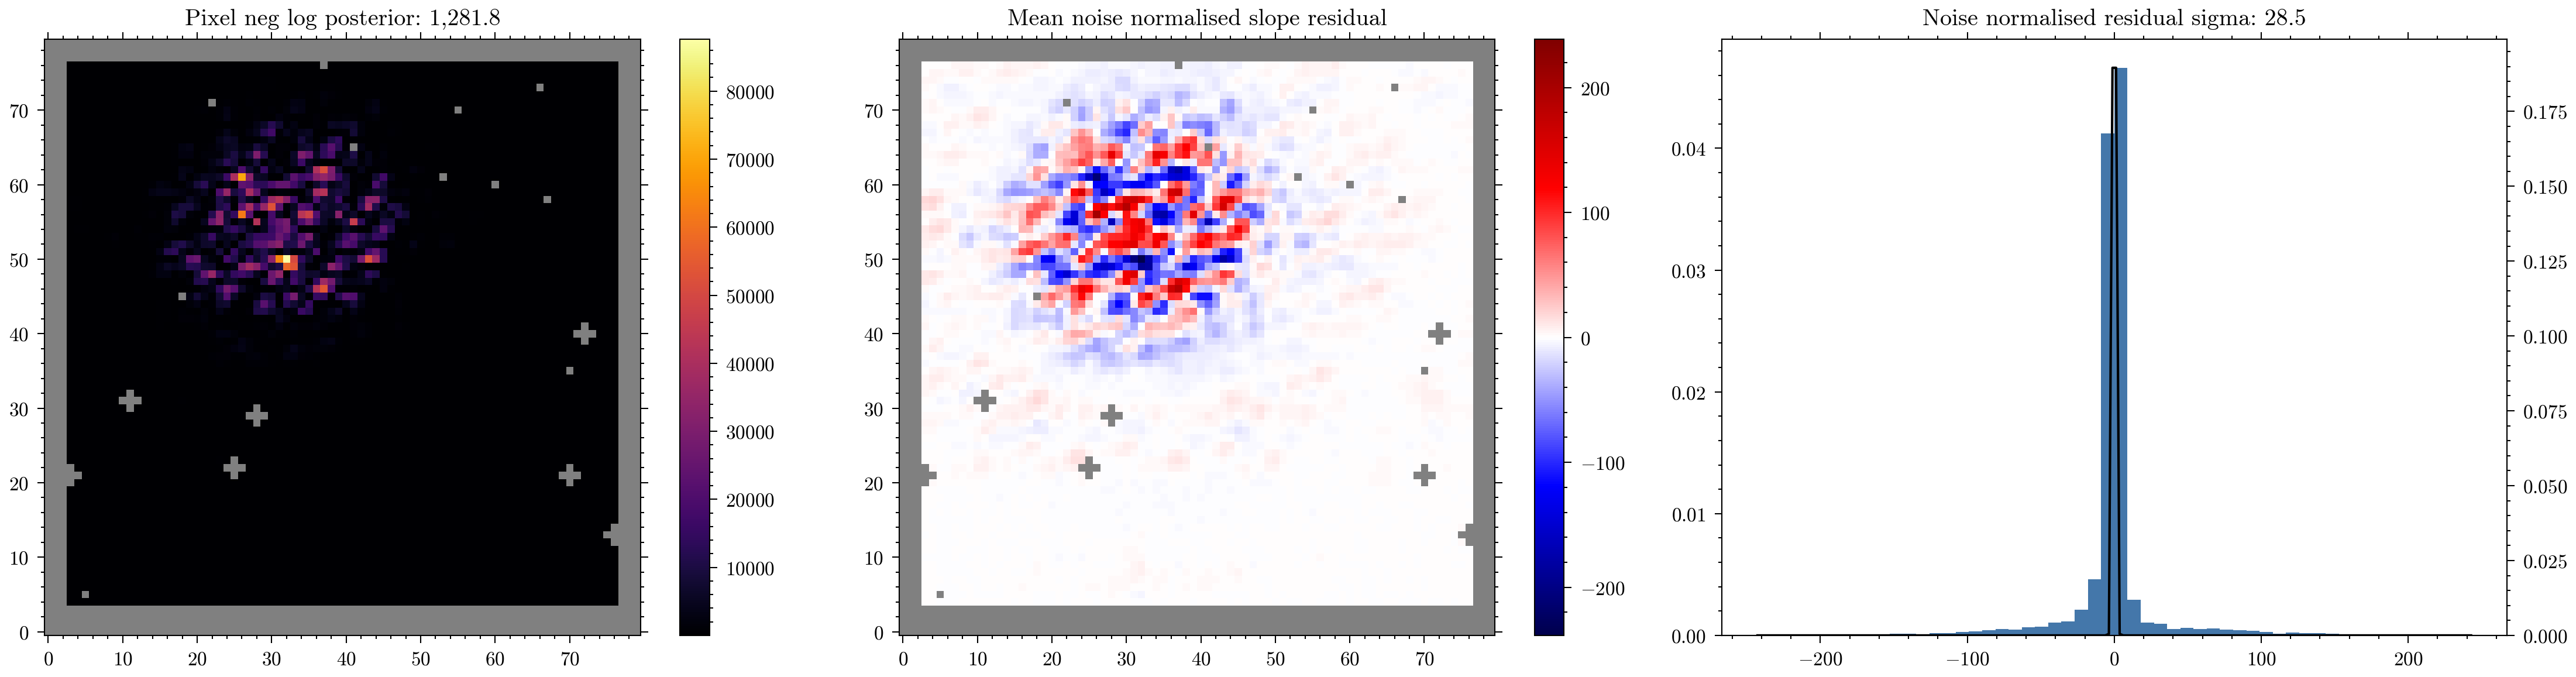

File 01349_003_02_03_3
Star WR137
Filter F480M
nints 400
ngroups 4

191.4439403835294


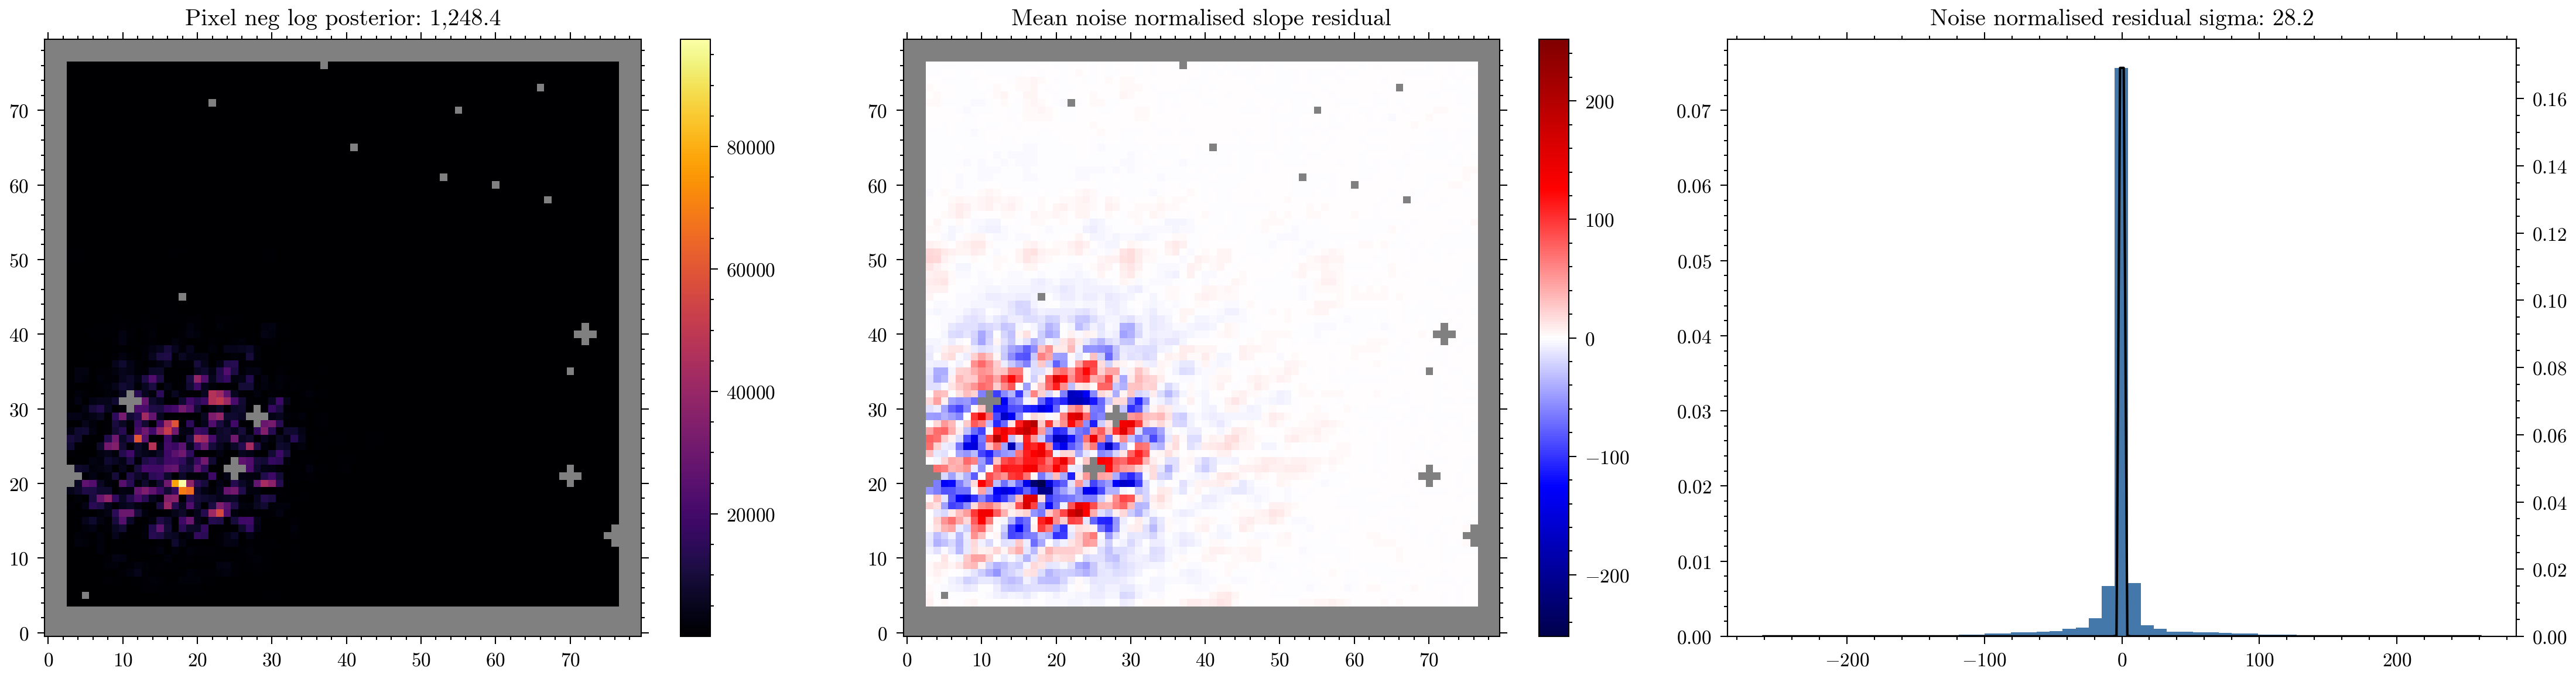

File 01349_003_02_03_4
Star WR137
Filter F480M
nints 400
ngroups 4

191.44331177807683


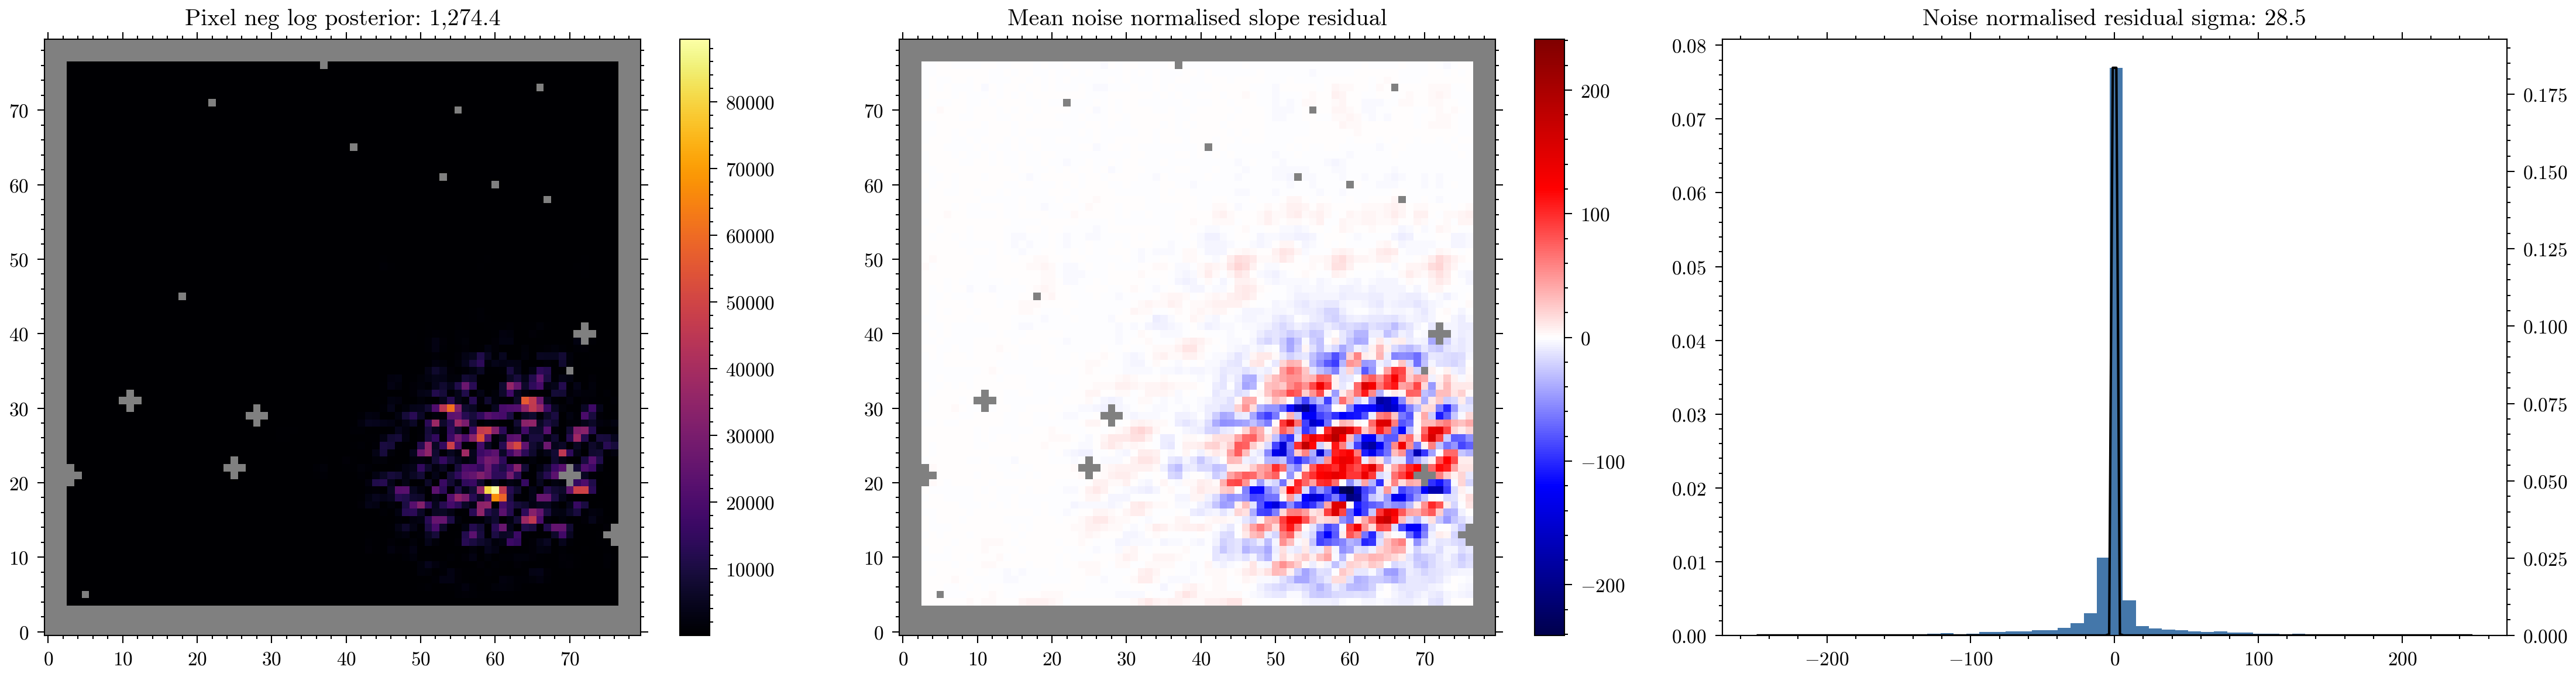

File 01349_006_02_03_1
Star WR137
Filter F480M
nints 1600
ngroups 4

189.27297266514145


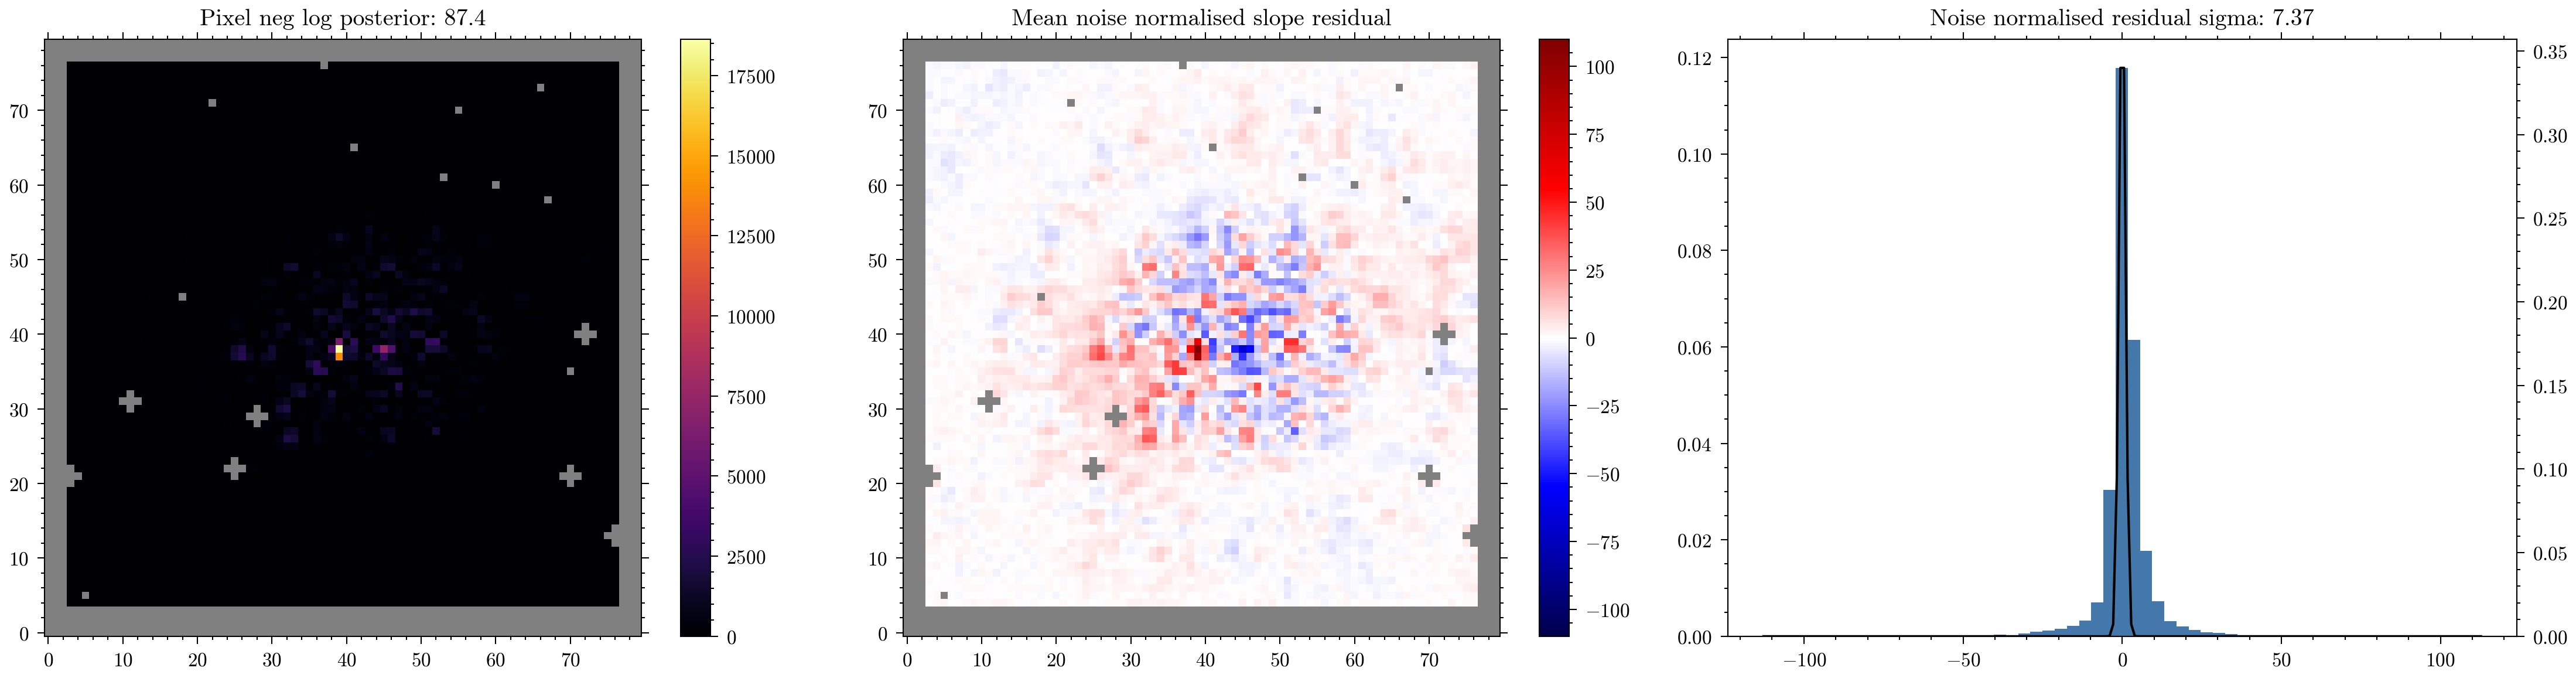

File 01349_053_02_03_1
Star WR137
Filter F480M
nints 400
ngroups 4

162.14609208445637


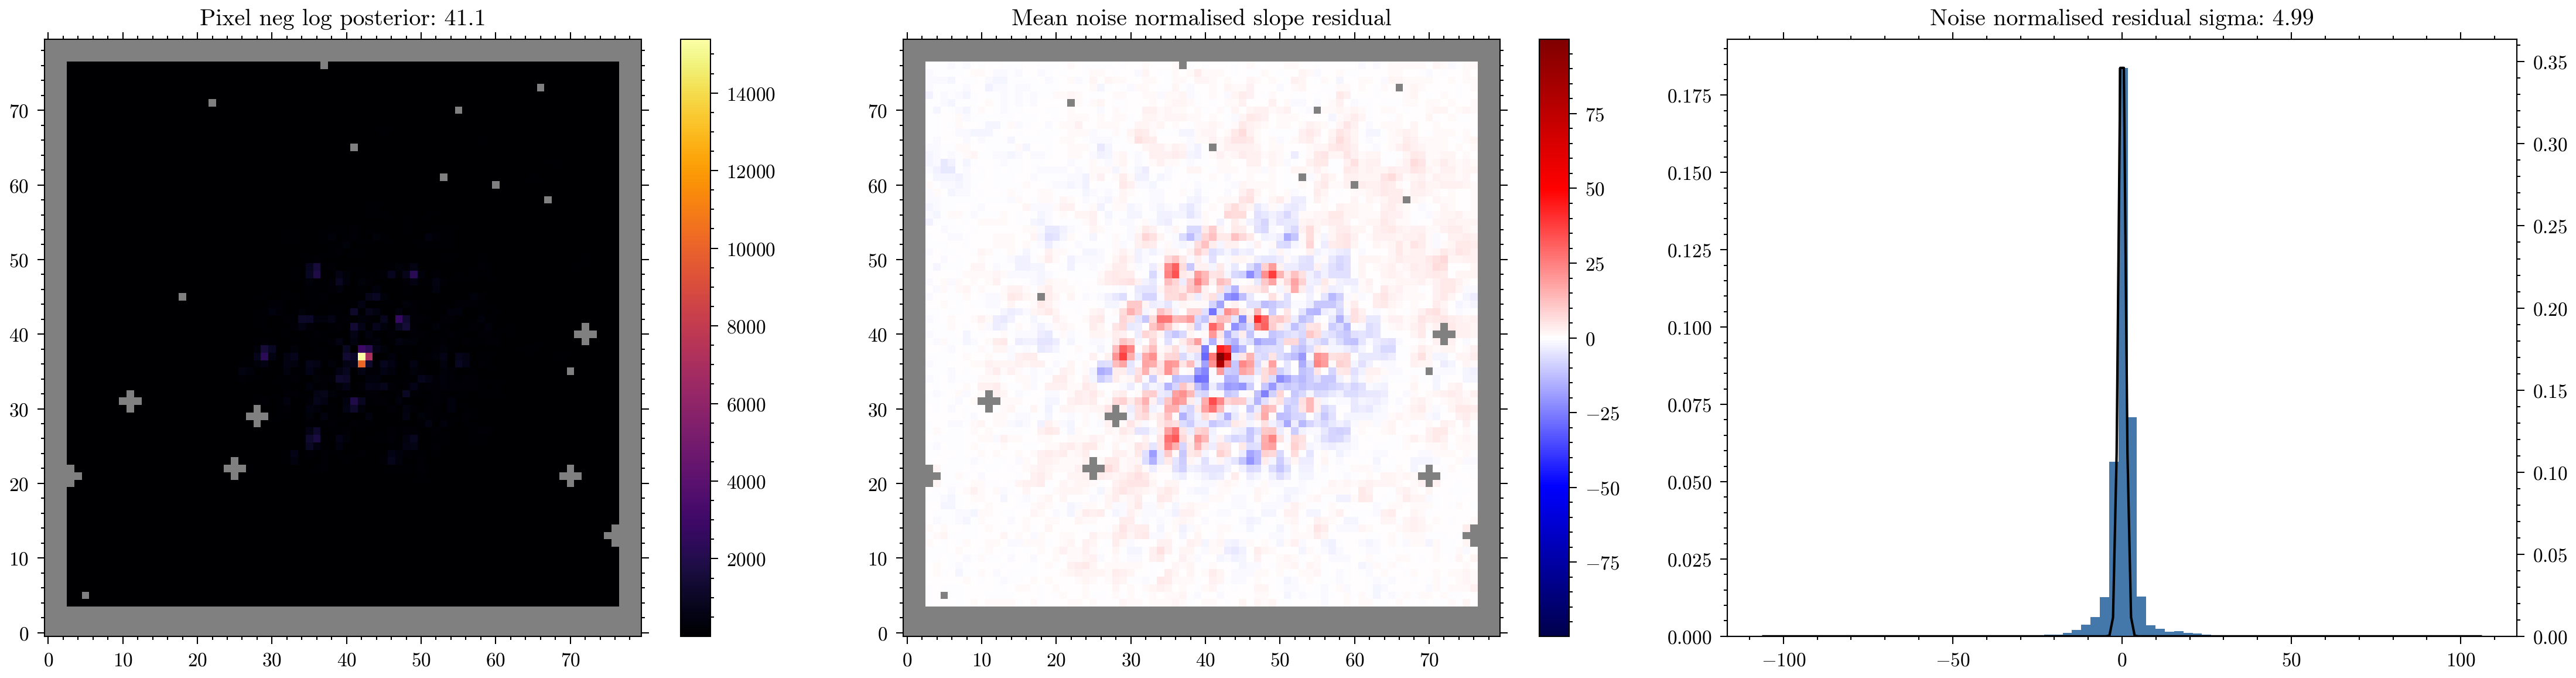

File 01349_053_02_03_2
Star WR137
Filter F480M
nints 400
ngroups 4

162.14615303890557


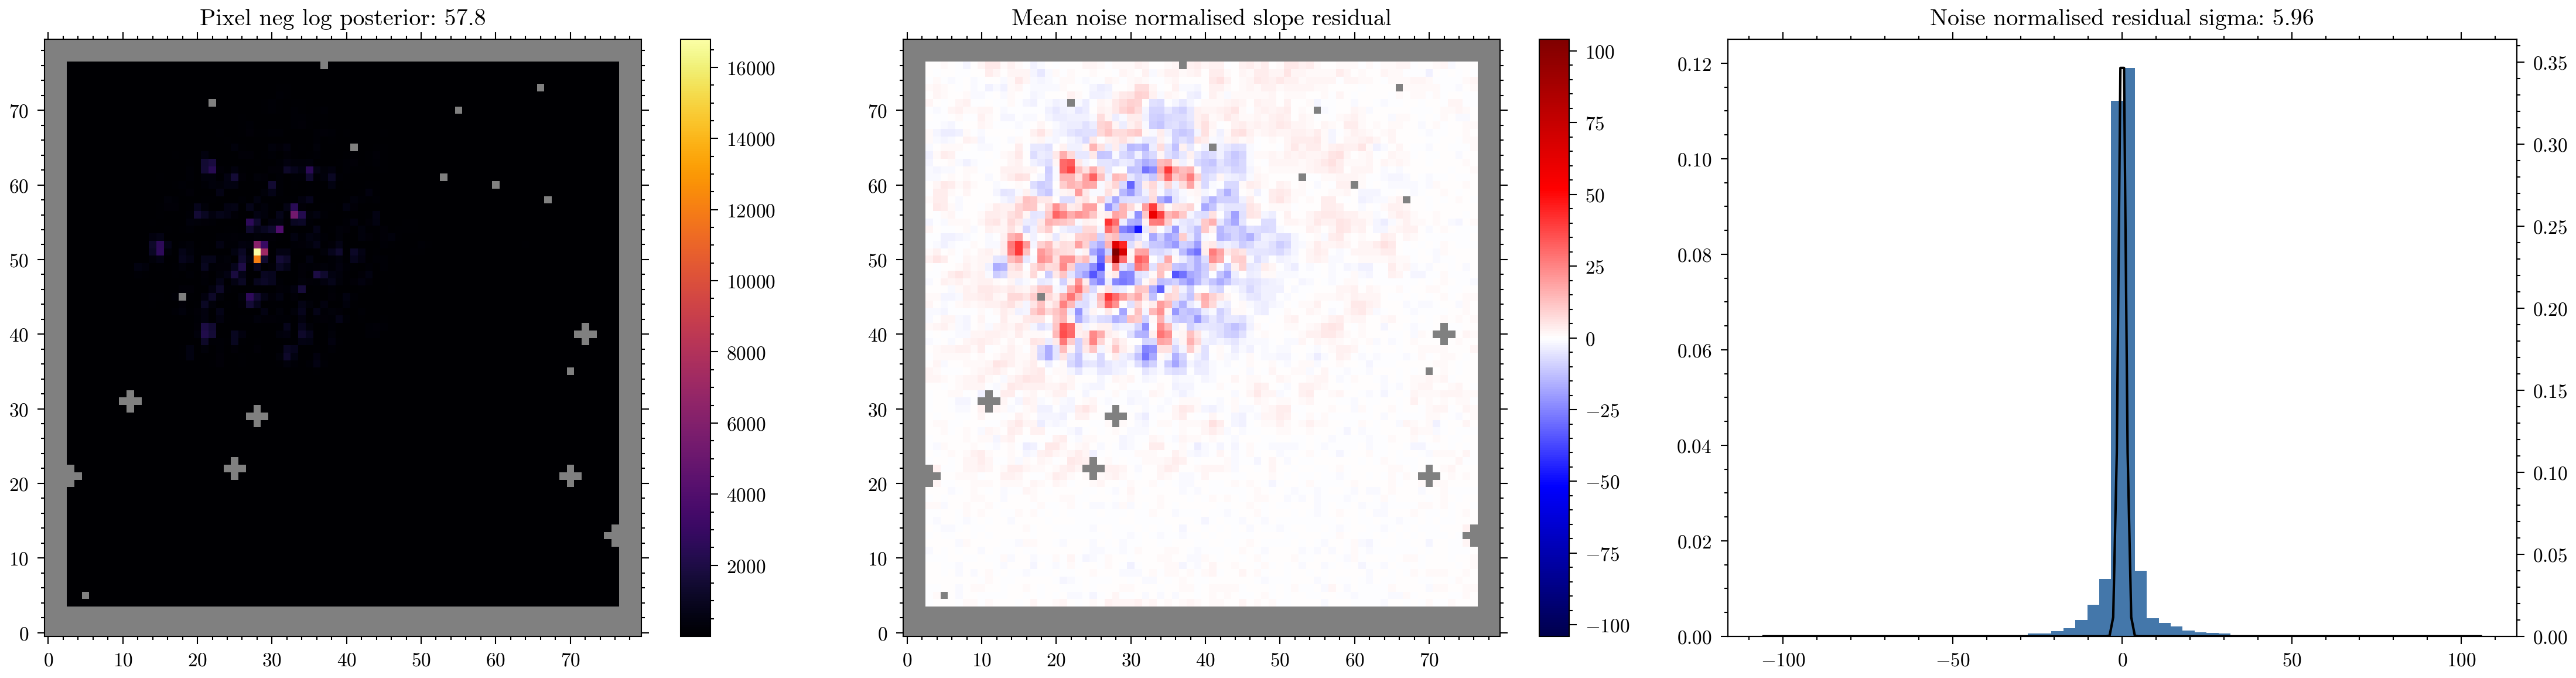

File 01349_053_02_03_3
Star WR137
Filter F480M
nints 400
ngroups 4

162.14647686762999


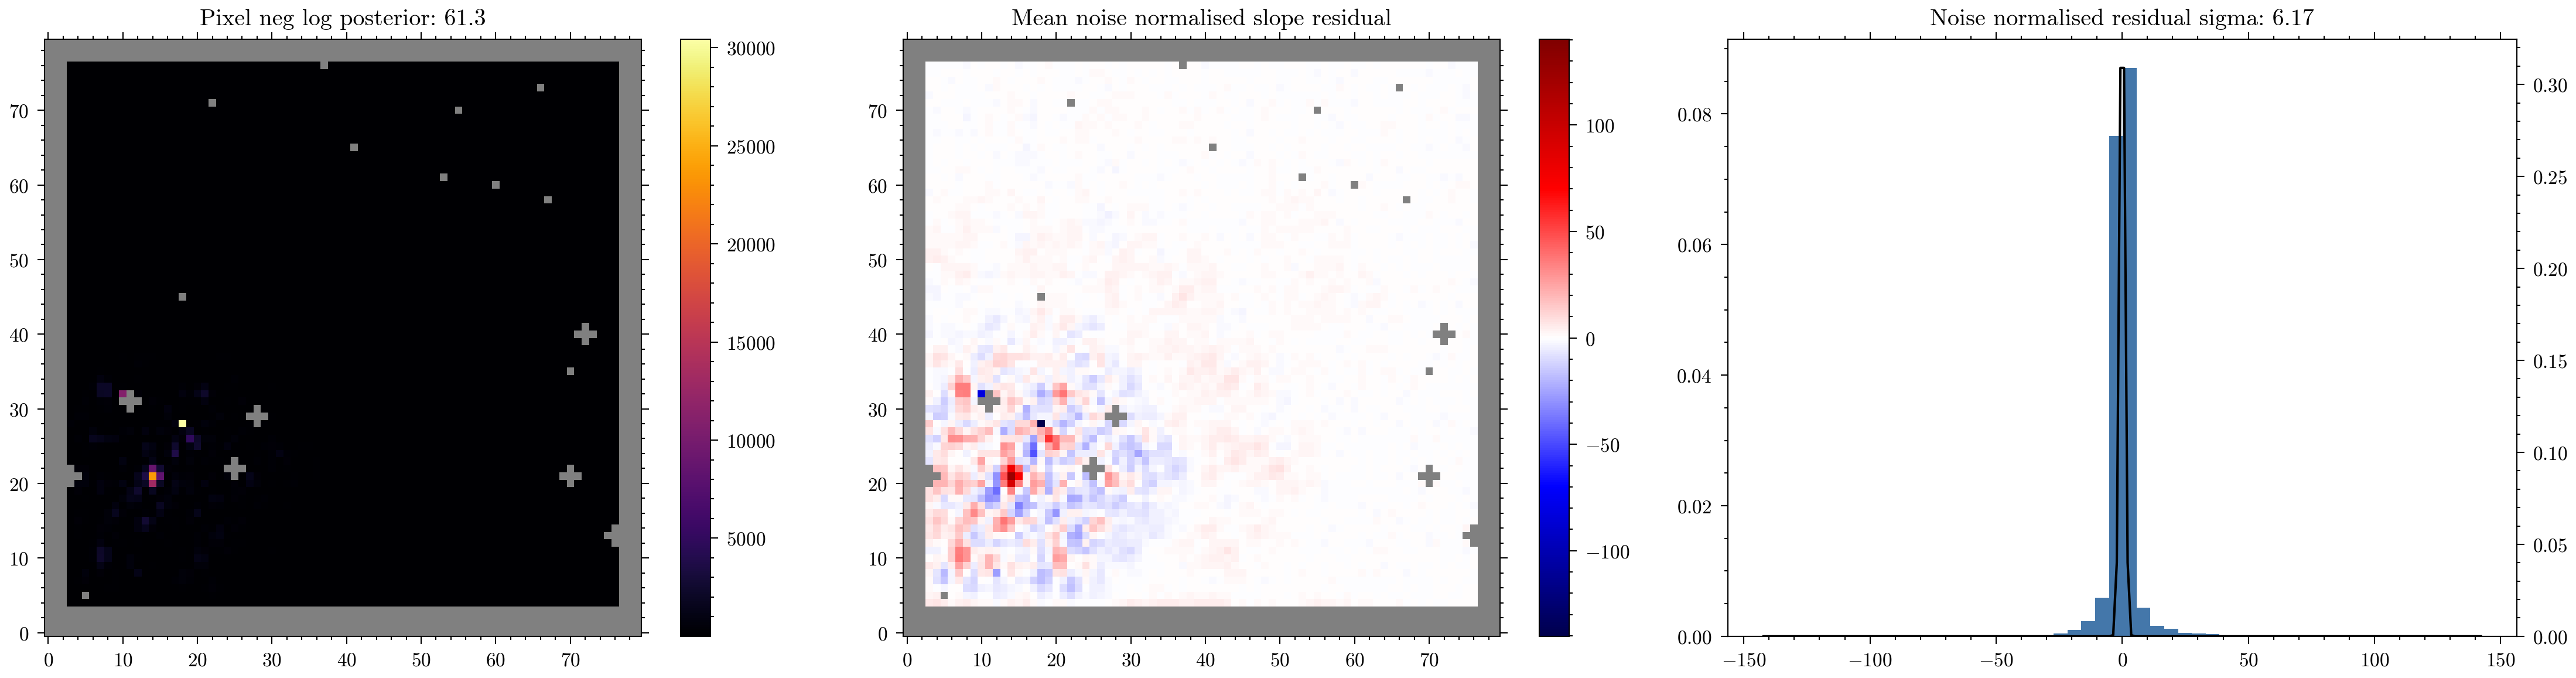

File 01349_053_02_03_4
Star WR137
Filter F480M
nints 400
ngroups 4

162.14593515733677


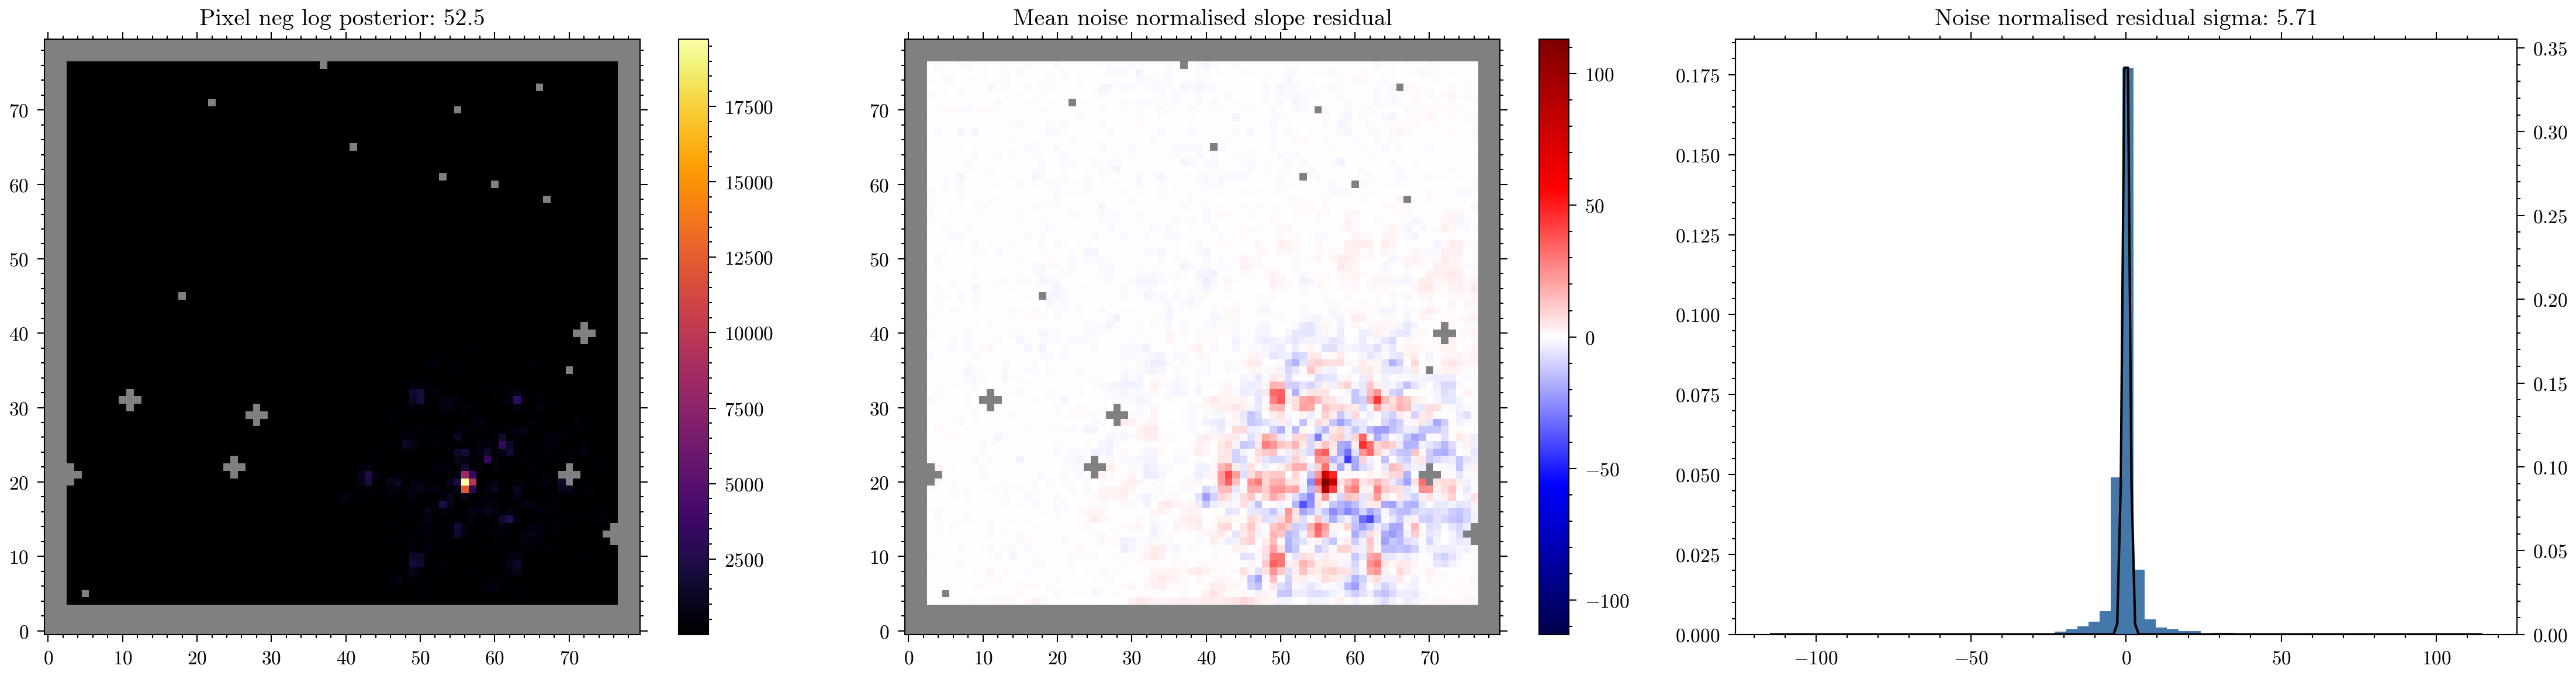

In [14]:
# np.save(init_state_cache + "closein500.npy", result.model.params)

flag = False
for exp in fits:

    try:
        if not flag:
            try:
                dist = result.model.get_distribution(exp)
            except:
                dist = exp.get_distribution(result.model)

            fig, ax = plt.subplots(1, 2, figsize=(6, 2.3))

            c0 = dorito.plotting.plot_result(
                ax[0],
                dist,
                # roll_angle_degrees=-rolls[exp.filename],
                cmap="afmhot_10u",
                power=0.5,
                vmin=0,
            )

            c1 = dorito.plotting.plot_result(
                ax[1],
                dorito.misc.blur_distribution(dist, result.model, exp, factor=0.5),
                cmap="afmhot_10u",
                power=0.3,
                vmin=None,
                # roll_angle_degrees=-rolls[exp.filename],
                # model=hdb_final_model,
            )
            fig.colorbar(c1, ax=ax[1])

            fig.colorbar(c0)
            # pa = model.params["position_angles"][exp.key]
            ax[0].set_title(f"WR137 - {exp.filter}")
            ax[1].set(title=r"Convolved - $\lambda / 2D$")

            plt.tight_layout()
            # plt.savefig(output_path + f"{time}.png", dpi=300)
            # plt.close()
            plt.show()
        # flag = True
    except:
        continue

amigo.plotting.plot_losses(result.losses[0], start=int(n_epoch * 0.75))
amigo.plotting.plot(result.history)

for exp in fits:
    exp.print_summary()
    print(model.params["position_angles"][exp.key])
    if exp.ngroups > 2:
        amigo.plotting.summarise_fit(
            result.model,
            exp,
            # residuals=True,
        )

In [ ]:
# wavelets = result.model.wavelets.update_distribution(
#     result.model.get_distribution(sci_fits[0]), normalise=False
# )
# dorito.plotting.tree_plot(wavelets.coeffs)